# Coarse Full Waveform Inversion

1. https://www.kaggle.com/competitions/waveform-inversion/code
2. https://www.kaggle.com/code/hanchenwang114/waveform-inversion-kaggle-competition-tutorial/notebook
3. https://arxiv.org/abs/2111.02926

## Imports

In [1]:
import os,sys; sys.path.append(os.getcwd().replace("fwi",""))
from util import get_torch_device_backend
from acoustic_forward_solver import acoustic_forward_solver, FWIPARAMETERS
from gauss_newton_solver import fwi_gn_solver
import chonknoris
import torch
import gpytorch
import lightning 
from matplotlib import pyplot,colors,cm
import os
import glob
import pandas as pd
import numpy as np
import timeit
import neuralop
import time 
import pyKoLesky.cholesky
import qmcpy as qp  # qmcpy==1.6.3rc0
import fastgps # fastgps==0.0.4.1b0
import warnings

## Torch Setup

In [2]:
torch.set_default_dtype(torch.float64)
torch.manual_seed(17)
DEVICE,TORCH_BACKEND = get_torch_device_backend(deviceidx=0)
print("DEVICE = %s"%str(DEVICE))
print("TORCH_BACKEND = %s"%str(TORCH_BACKEND.__name__))
EPS = torch.finfo(torch.get_default_dtype()).eps
EPS

DEVICE = cuda:0
TORCH_BACKEND = torch.cuda


2.220446049250313e-16

## Boilderplate

In [3]:
ROOT = "."
assert os.path.isfile(ROOT+"/fwi.ipynb")

In [4]:
pyplot.style.use('seaborn-v0_8-whitegrid')
COLORS = ["xkcd:"+color[:-1] for color in pd.read_csv(ROOT+"/../xkcd_colors.txt",comment="#",header=None).iloc[:,0].tolist()][::-1]
COLORS[:3] = COLORS[:3][::-1]
LWTHICK = 3
LWTHIN = .05
HIGHLIGHTS = 4

## Load Dataset

In [35]:
pname = "RES7"
vtype = "Style_B"
tag = "RELAX_1e+01"
custom_rkhs_v = False
custom_rkhs_w = False
outdir = './data/%s/%s'%(pname,vtype)
assert os.path.isdir(outdir)
p = FWIPARAMETERS[pname]
for _key,_val in p.items():
    print("p['%s'] = %s"%(_key,_val))
print()
_data_split = torch.load(outdir+"/split_train_val.pt",weights_only=True)
_data_nk = torch.load(outdir+"/NK.%s.RKHS_v_%s.RKHS_w_%s.pt"%(tag,"custom" if custom_rkhs_v else "eye","custom" if custom_rkhs_w else "eye"),weights_only=True)
data = {**_data_split,**_data_nk}
for _key,_val in data.items():
    print("data['%s'].shape = %s"%(_key,str(tuple(_val.shape))))
print()
R,Ns,Nt,Nx = data["wavefield"].shape
Thetainv_v = torch.load(outdir+"/RKHS_v_%s.pt"%("custom" if custom_rkhs_v else "eye"),weights_only=True)["Thetainv"]
Thetainv_w = torch.load(outdir+"/RKHS_w_%s.pt"%("custom" if custom_rkhs_w else "eye"),weights_only=True)["Thetainv"]
print("Thetainv_v.shape = %s"%str(tuple(Thetainv_v.shape)))
print("Thetainv_w.shape = %s"%str(tuple(Thetainv_w.shape)))

p['name'] = RES7
p['nx'] = 7
p['dx'] = 10
p['nbc'] = 12
p['nt'] = 101
p['dt'] = 0.001
p['freq'] = 35
p['coord_sx'] = [1.0, 17.5, 35.0, 53.0, 70.0]
p['coord_sz'] = [1, 1, 1, 1, 1]

data['velocity'].shape = (1000, 7, 7)
data['wavefield'].shape = (1000, 5, 100, 7)
data['velocity_train'].shape = (800, 7, 7)
data['velocity_val'].shape = (200, 7, 7)
data['wavefield_train'].shape = (800, 5, 100, 7)
data['wavefield_val'].shape = (200, 5, 100, 7)
data['tidxs'].shape = (800,)
data['vidxs'].shape = (200,)
data['vs'].shape = (1000, 51, 7, 7)
data['rmses'].shape = (1000, 51)
data['times'].shape = (51,)
data['relaxations'].shape = (1000, 51)
data['lrs'].shape = (1000, 51)
data['updated'].shape = (1000, 50)
data['Linvs'].shape = (1000, 50, 49, 49)
data['cond_nums'].shape = (1000, 50)
data['l2rerrors'].shape = (1000, 51)
data['v_true'].shape = (1000, 7, 7)
data['w_true'].shape = (1000, 5, 100, 7)

Thetainv_v.shape = (49, 49)
Thetainv_w.shape = (5, 700, 700)


## Explore Dataset

In [6]:
print("L2 relative errors")
with pd.option_context('display.max_rows', None, 'display.max_columns', None):  # more options can be specified also
    display(pd.DataFrame(data["l2rerrors"]).describe().T.iloc[::5])

L2 relative errors


,count,mean,std,min,25%,50%,75%,max
0,1000.0,8.084552e-02,1.065192e-02,5.897706e-02,7.390346e-02,7.920822e-02,8.595170e-02,1.605118e-01
5,1000.0,2.812164e-02,2.119210e-02,2.791461e-03,1.602648e-02,2.308737e-02,3.273605e-02,1.913488e-01
10,1000.0,7.420822e-03,7.996472e-03,1.859105e-05,2.227424e-03,5.318816e-03,1.018826e-02,8.796184e-02
15,1000.0,7.204213e-04,2.440164e-03,8.610461e-12,1.893506e-06,2.040904e-05,2.746475e-04,3.103318e-02
20,1000.0,3.381156e-05,4.665376e-04,1.066583e-14,9.402906e-12,1.541099e-09,2.828850e-08,9.965407e-03
25,1000.0,7.766116e-07,1.721662e-05,6.503505e-15,3.983672e-14,8.774507e-14,8.129931e-13,4.260230e-04
30,1000.0,5.820838e-11,1.803928e-09,6.344348e-15,3.117324e-14,5.274002e-14,1.069017e-13,5.704172e-08
35,1000.0,1.133821e-13,9.723250e-13,6.306123e-15,3.013115e-14,5.032020e-14,9.519073e-14,3.069554e-11
40,1000.0,8.225775e-14,8.991602e-14,6.306123e-15,3.013115e-14,5.006827e-14,9.401935e-14,7.366771e-13
45,1000.0,8.207641e-14,8.983840e-14,6.306123e-15,3.007731e-14,4.987216e-14,9.381093e-14,7.366771e-13


In [7]:
print("Relaxations")
with pd.option_context('display.max_rows', None, 'display.max_columns', None):  # more options can be specified also
    display(pd.DataFrame(data["relaxations"]).describe().T.iloc[::5])

Relaxations


,count,mean,std,min,25%,50%,75%,max
0,1000.0,10.000000,0.000000,10.000000,10.000000,10.000000,10.000000,1.000000e+01
5,1000.0,6.503125,5.233870,0.625000,2.500000,5.000000,10.000000,4.000000e+01
10,1000.0,0.436680,0.840456,0.039062,0.156250,0.312500,0.625000,2.000000e+01
15,1000.0,0.040302,0.068385,0.001221,0.009766,0.019531,0.039062,1.250000e+00
20,1000.0,0.012118,0.020785,0.000076,0.001221,0.004883,0.019531,3.125000e-01
25,1000.0,0.007763,0.024022,0.000010,0.000610,0.002441,0.004883,6.250000e-01
30,1000.0,0.094752,0.696415,0.000005,0.002441,0.009766,0.039062,2.000000e+01
35,1000.0,2.925152,22.292353,0.000019,0.019531,0.156250,1.250000,6.400000e+02
40,1000.0,93.537526,713.363874,0.000305,0.625000,5.000000,40.000000,2.048000e+04
45,1000.0,2993.199077,22827.644204,0.004883,20.000000,160.000000,1280.000000,6.553600e+05


In [8]:
print("Learning rates")
with pd.option_context('display.max_rows', None, 'display.max_columns', None):  # more options can be specified also
    display(pd.DataFrame(data["lrs"]).describe().T.iloc[::5])

Learning rates


,count,mean,std,min,25%,50%,75%,max
0,1000.0,1.000000,0.000000,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000
5,1000.0,1.474000,0.499573,1.000000e+00,1.000000e+00,1.000000e+00,2.000000e+00,2.000000
10,1000.0,1.795000,0.625593,1.000000e+00,1.000000e+00,2.000000e+00,2.000000e+00,4.000000
15,1000.0,1.518000,0.622948,1.000000e+00,1.000000e+00,1.000000e+00,2.000000e+00,4.000000
20,1000.0,1.196875,0.477542,1.250000e-01,1.000000e+00,1.000000e+00,1.000000e+00,4.000000
25,1000.0,0.639371,0.519270,3.906250e-03,2.500000e-01,5.000000e-01,1.000000e+00,2.000000
30,1000.0,0.153986,0.288944,1.220703e-04,7.812500e-03,3.125000e-02,1.250000e-01,2.000000
35,1000.0,0.023754,0.085671,3.814697e-06,2.441406e-04,1.953125e-03,7.812500e-03,1.000000
40,1000.0,0.001873,0.017173,1.192093e-07,7.629395e-06,6.103516e-05,2.441406e-04,0.500000
45,1000.0,0.000132,0.002066,3.725290e-09,2.384186e-07,1.907349e-06,7.629395e-06,0.062500


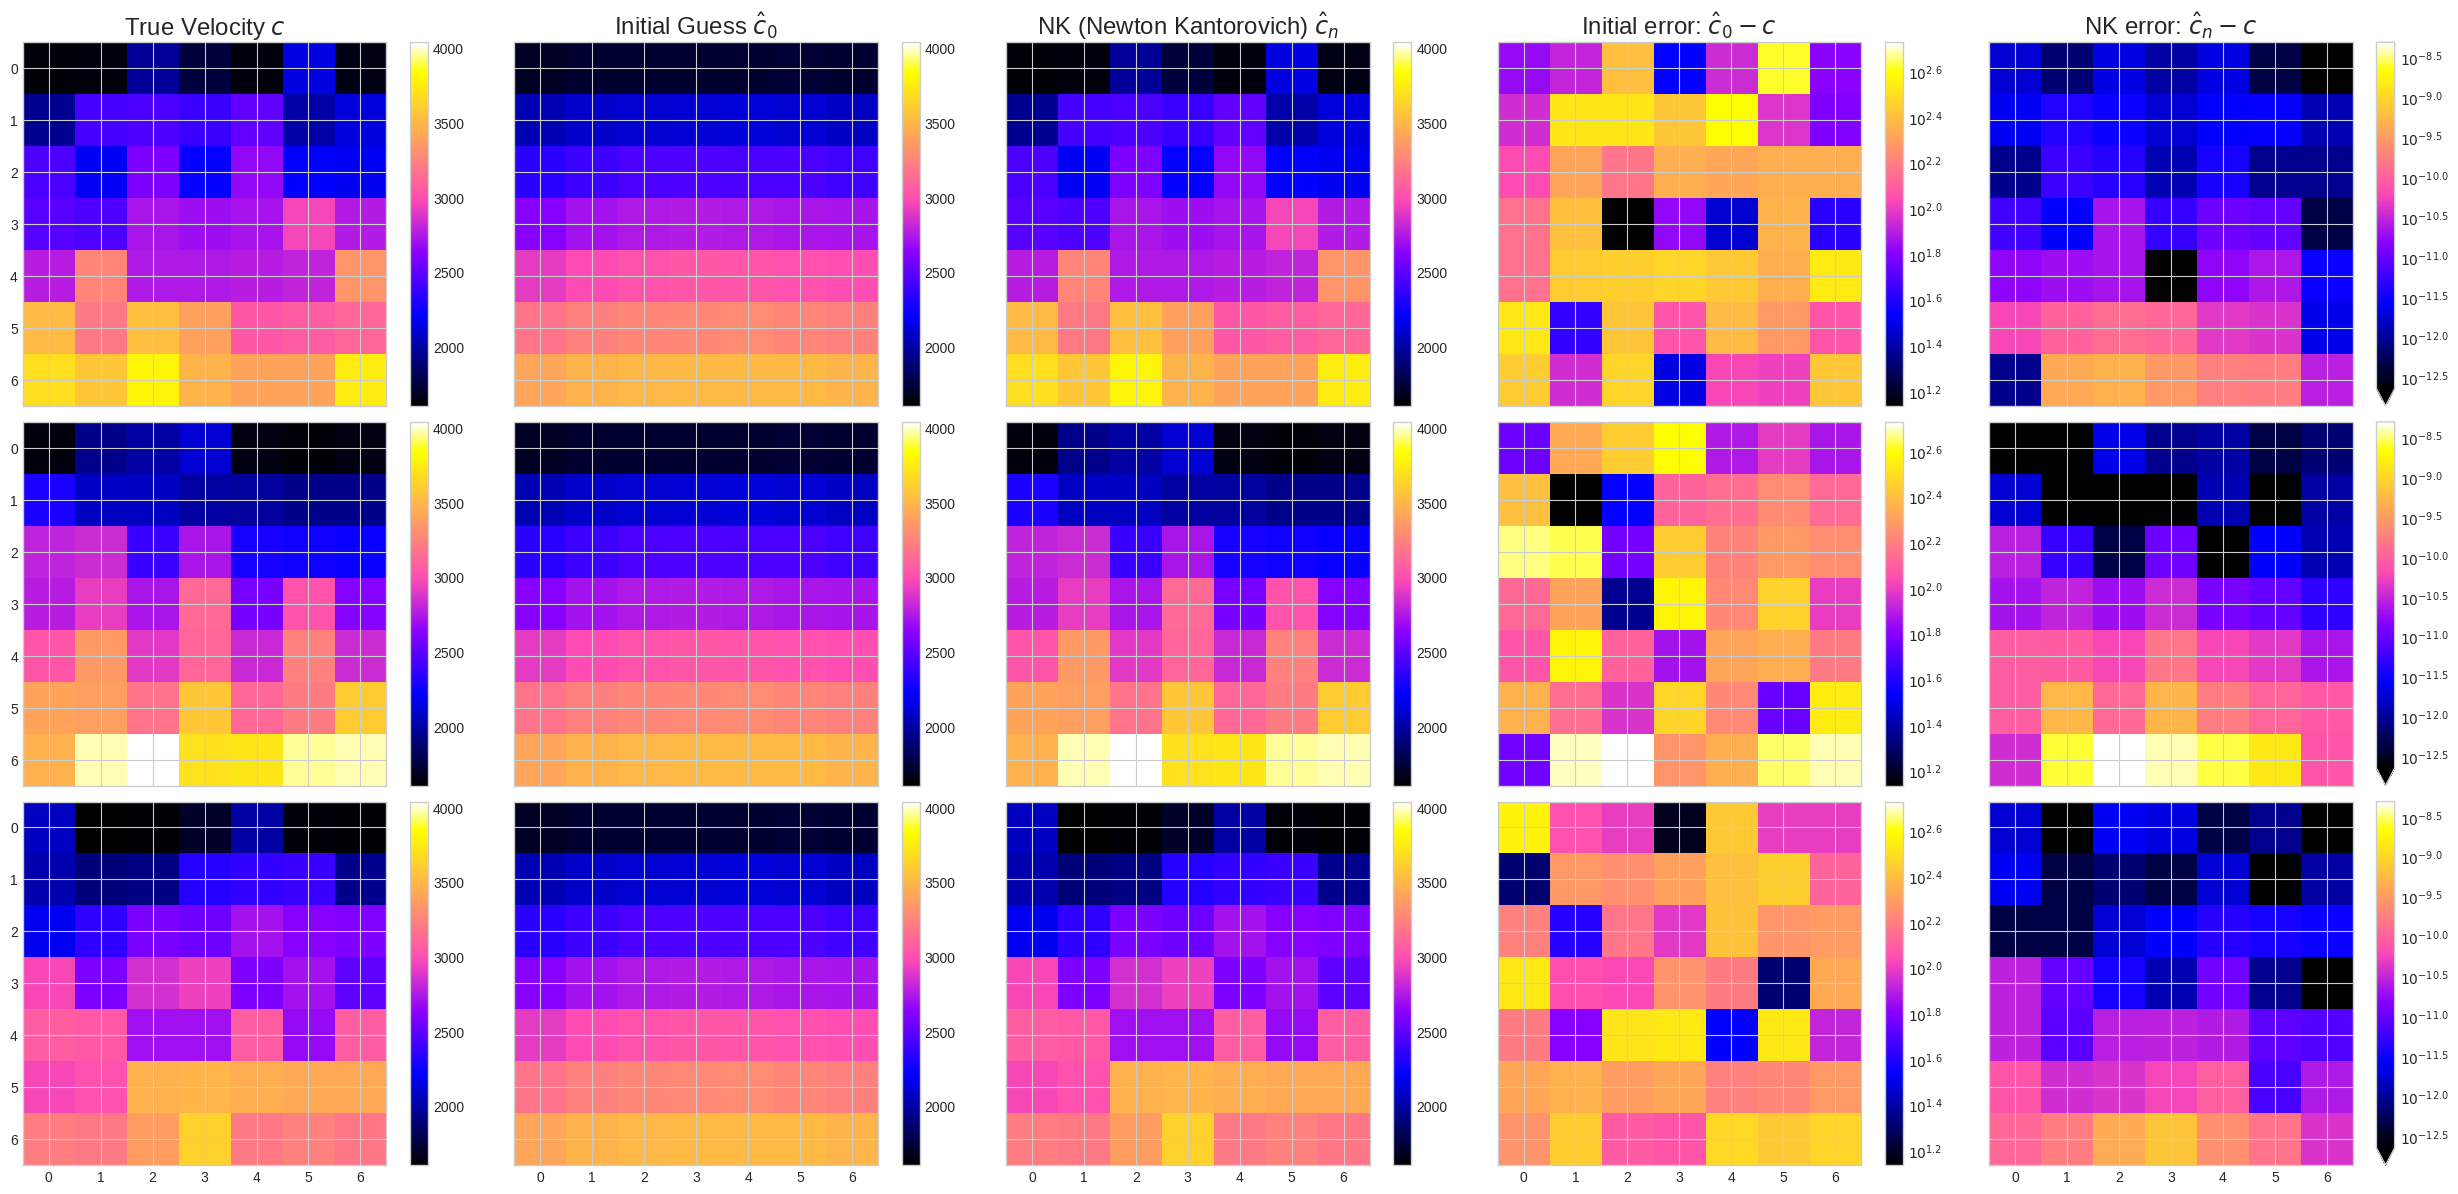

In [9]:
def plot_nk_velocities(v_true, v0, vfinal):
    initial_error_log10 = torch.log10(torch.abs(v_true-v0))
    final_error_log10 = torch.log10(torch.abs(v_true-vfinal))
    final_error_log10[final_error_log10==-torch.inf] = final_error_log10[final_error_log10.isfinite()].min()
    _initial_error_log10_amin = initial_error_log10.min()
    _initial_error_log10_amax = initial_error_log10.max()
    _final_error_log10_amin = final_error_log10.min()
    _final_error_log10_amax = final_error_log10.max()
    _cbmin = torch.min(v_true.min(),v0.min())
    _cbmax = torch.max(v_true.max(),v0.max())
    _plot_data = [
        (v_true,r"True Velocity $c$",_cbmin,_cbmax,False,None),
        (v0,r"Initial Guess $\hat{c}_0$",_cbmin,_cbmax,False,None),
        (vfinal,r"NK (Newton Kantorovich) $\hat{c}_n$",_cbmin,_cbmax,False,None),
        (initial_error_log10,r"Initial error: $\hat{c}_0-c$",_initial_error_log10_amin,_initial_error_log10_amax,True,None),
        (final_error_log10,r"NK error: $\hat{c}_n-c$",_final_error_log10_amin,_final_error_log10_amax,True,"min"),
        ]
    nrows = _plot_data[0][0].size(0)
    ncols = len(_plot_data)
    fig,ax = pyplot.subplots(nrows=nrows,ncols=ncols,figsize=(5*ncols,4*nrows),sharex=True,sharey=True)
    ax = ax.reshape((nrows,ncols))
    for j,(_v,name,_vmin,_vmax,log10ed,extend) in enumerate(_plot_data):
        for i in range(nrows):
            cax = ax[i,j].imshow(_v[i].cpu(),cmap="gnuplot2",vmin=_vmin if _vmin is not None else None,vmax=_vmax if _vmax is not None else None)
            cbar = fig.colorbar(cax,extend=extend)
            if log10ed:
                with warnings.catch_warnings():
                    warnings.simplefilter("ignore",UserWarning)
                    cbar.ax.set_yticklabels([r"$10^{%.1f}$"%(int(_tick) if _tick%1==0 else _tick) for _tick in cbar.ax.get_yticks()]) 
        ax[0,j].set_title(name,fontsize="xx-large")
    fig.tight_layout()
    return fig,ax 
_R = 3
fig,ax = plot_nk_velocities(data["velocity"][:_R],data["vs"][:_R,0],data["vs"][:_R,-1])
fig.savefig(outdir+"/fwi_data.png",dpi=256)

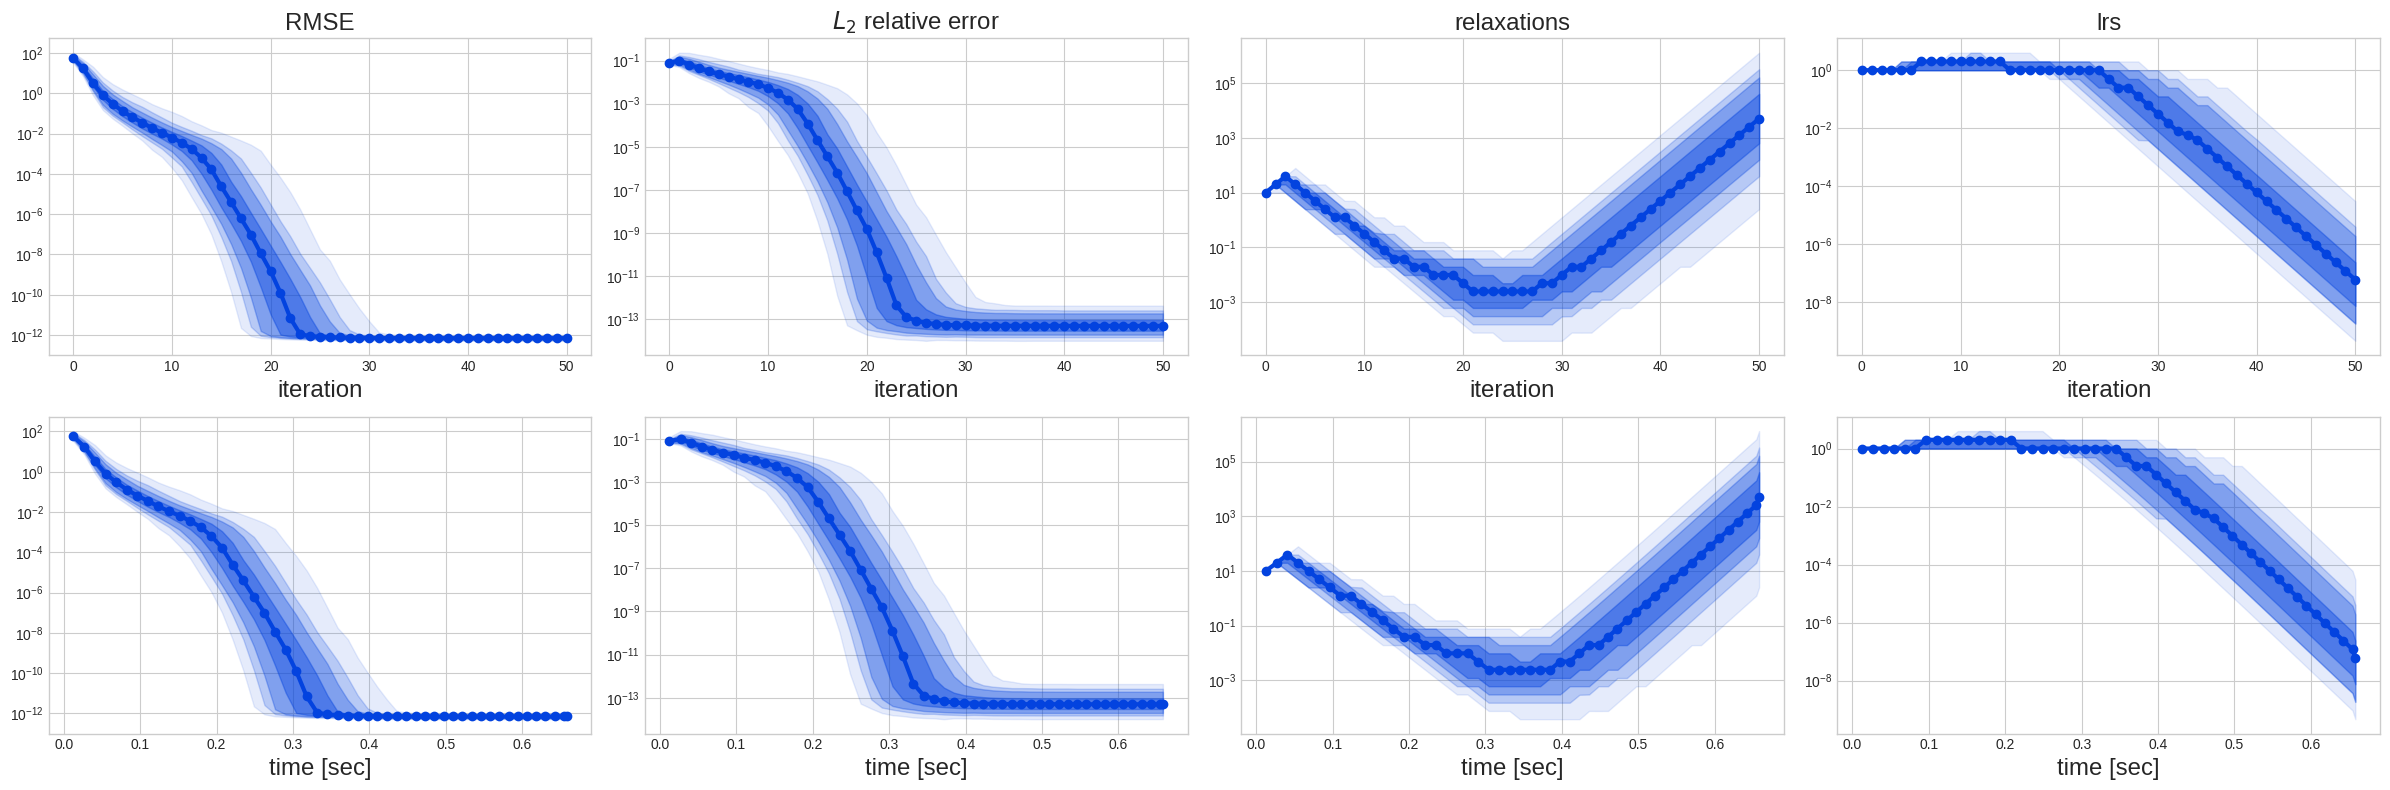

In [10]:
fig,ax = chonknoris.plot_band_strand(
    data = [
        [
            [(None,data["rmses"],None)],
            [(None,data["l2rerrors"],None)],
            [(None,data["relaxations"],None)],
            [(None,data["lrs"],None)],

        ],
        [
            [(data["times"].cumsum(0),data["rmses"],None)],
            [(data["times"].cumsum(0),data["l2rerrors"],None)],
            [(data["times"].cumsum(0),data["relaxations"],None)],
            [(data["times"].cumsum(0),data["lrs"],None)],

        ],
    ],
    sharex = False,
    titles = [["RMSE",r"$L_2$ relative error","relaxations","lrs"],[None,None,None,None]],
    xlabels = [["iteration"],["time [sec]"]],
    xlogscale = False,
    colors = [COLORS[0]],
    ylogscale = True,
    fsx=4,fsy=6,
    legends=False)
fig.tight_layout()
fig.savefig(outdir+"/fwi_coarse_nk_convergence.pdf",bbox_inches="tight")

## Initial Guess Model

### Load Data

In [11]:
outdir_igmodels = outdir+"/MODELS_IG"
if not os.path.isdir(outdir_igmodels): os.mkdir(outdir_igmodels)

In [12]:
# inputs 
inputs_raw_ig_t = data["wavefield"][data["tidxs"]].flatten(start_dim=1)
inputs_raw_ig_v = data["wavefield"][data["vidxs"]].flatten(start_dim=1)
inputs_raw_ig_t_mean = inputs_raw_ig_t.mean(0) 
inputs_raw_ig_t_std = inputs_raw_ig_t.std(0)
inputs_raw_ig_t_std[inputs_raw_ig_t_std==0] = 1
inputs_raw_ig_t_mean[:] = 0 # UNCOMMENT TO AVOID INPUT STANDARDIZATION
inputs_raw_ig_t_std[:] = 1 # UNCOMMENT TO AVOID INPUT STANDARDIZATION
inputs_ig_t = (inputs_raw_ig_t-inputs_raw_ig_t_mean)/inputs_raw_ig_t_std
inputs_ig_v = (inputs_raw_ig_v-inputs_raw_ig_t_mean)/inputs_raw_ig_t_std
print("inputs_raw_ig_t.shape = %s"%str(tuple(inputs_raw_ig_t.shape)))
print("inputs_raw_ig_v.shape = %s"%str(tuple(inputs_raw_ig_v.shape)))
print("inputs_raw_ig_t_mean.shape = %s"%str(tuple(inputs_raw_ig_t_mean.shape)))
print("inputs_raw_ig_t_std.shape = %s"%str(tuple(inputs_raw_ig_t_std.shape)))
print("inputs_ig_t.shape = %s"%str(tuple(inputs_ig_t.shape)))
print("inputs_ig_v.shape = %s\n"%str(tuple(inputs_ig_v.shape)))
# outputs
outputs_raw_ig_t = torch.log(data["velocity"][data["tidxs"]].flatten(start_dim=1))
outputs_raw_ig_v = torch.log(data["velocity"][data["vidxs"]].flatten(start_dim=1))
outputs_raw_ig_t_mean = outputs_raw_ig_t.mean(0) 
outputs_raw_ig_t_std = outputs_raw_ig_t.std(0) 
outputs_raw_ig_t_std[outputs_raw_ig_t_std==0] = 1
outputs_raw_ig_t_mean[:] = 0 # UNCOMMENT TO AVOID OUTPUT STANDARDIZATION
outputs_raw_ig_t_std[:] = 1 # UNCOMMENT TO AVOID OUTPUT STANDARDIZATION
outputs_ig_t = (outputs_raw_ig_t-outputs_raw_ig_t_mean)/outputs_raw_ig_t_std
outputs_ig_v = (outputs_raw_ig_v-outputs_raw_ig_t_mean)/outputs_raw_ig_t_std
print("outputs_raw_ig_t.shape = %s"%str(tuple(outputs_raw_ig_t.shape)))
print("outputs_raw_ig_v.shape = %s"%str(tuple(outputs_raw_ig_v.shape)))
print("outputs_raw_ig_t_mean.shape = %s"%str(tuple(outputs_raw_ig_t_mean.shape)))
print("outputs_raw_ig_t_std.shape = %s"%str(tuple(outputs_raw_ig_t_std.shape)))
print("outputs_ig_t.shape = %s"%str(tuple(outputs_ig_t.shape)))
print("outputs_ig_v.shape = %s"%str(tuple(outputs_ig_v.shape)))

inputs_raw_ig_t.shape = (800, 3500)
inputs_raw_ig_v.shape = (200, 3500)
inputs_raw_ig_t_mean.shape = (3500,)
inputs_raw_ig_t_std.shape = (3500,)
inputs_ig_t.shape = (800, 3500)
inputs_ig_v.shape = (200, 3500)

outputs_raw_ig_t.shape = (800, 49)
outputs_raw_ig_v.shape = (200, 49)
outputs_raw_ig_t_mean.shape = (49,)
outputs_raw_ig_t_std.shape = (49,)
outputs_ig_t.shape = (800, 49)
outputs_ig_v.shape = (200, 49)


### MLP

In [13]:
import gc
gc.collect()
torch.cuda.empty_cache()

save_dir = outdir_igmodels
name = "MLP"
resume = True

ds_ig_t = chonknoris.DatasetClassic(inputs_ig_t,outputs_ig_t)
ds_ig_v = chonknoris.DatasetClassic(inputs_ig_v,outputs_ig_v)
print("len(ds_ig_t) = %d"%len(ds_ig_t))
print("len(ds_ig_v) = %d"%len(ds_ig_v))

dl_mlp_ig_t = torch.utils.data.DataLoader(ds_ig_t,batch_size=2**8,collate_fn=tuple,shuffle=True)
dl_mlp_ig_v = torch.utils.data.DataLoader(ds_ig_v,batch_size=len(ds_ig_v),collate_fn=tuple,shuffle=False)
print("len(dl_mlp_t) = %d"%len(dl_mlp_ig_t))
print("len(dl_mlp_v) = %d"%len(dl_mlp_ig_v))
print()

nn_ig = chonknoris.MLP(mlp_layer_nodes=[Ns*Nt*Nx]+5*[Nx*Nx],activation_function=torch.nn.Tanh())
#nn = chonknoris.MLP(mlp_layer_nodes=[1+Nx**2+Ns*Nt*Nx]+5*[1000]+[Nx**2*(1+Nx**2)//2],activation_function=torch.nn.Tanh())
lnn_ig = chonknoris.LightningNN(nn_ig,lr=1e-3,use_l2rerror_loss=True).to(DEVICE)
print(lnn_ig)

csv_logger = lightning.pytorch.loggers.CSVLogger(save_dir=save_dir,name=name,version='csv')
trainer = lightning.Trainer(
    max_epochs = 100,
    logger = [csv_logger],
    #accelerator = "cpu",
    #limit_train_batches=2**10,
    #log_every_n_steps = 1e10,
    enable_progress_bar = True,
    #num_sanity_val_steps = 0,
    #gradient_clip_val = 1.0,
    #gradient_clip_algorithm = "norm",
  )
trainer.fit(
    model = lnn_ig, 
    train_dataloaders = dl_mlp_ig_t,
    val_dataloaders = dl_mlp_ig_v,
    ckpt_path = sorted(glob.glob("./%s/%s/csv/checkpoints/*.ckpt"%(save_dir,name)),key=os.path.getmtime)[-1] if resume else None,
)


len(ds_ig_t) = 800
len(ds_ig_v) = 200
len(dl_mlp_t) = 4
len(dl_mlp_v) = 1



Trainer will use only 1 of 7 GPUs because it is running inside an interactive / notebook environment. You may try to set `Trainer(devices=7)` but please note that multi-GPU inside interactive / notebook environments is considered experimental and unstable. Your mileage may vary.
Using default `ModelCheckpoint`. Consider installing `litmodels` package to enable `LitModelCheckpoint` for automatic upload to the Lightning model registry.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
You are using a CUDA device ('NVIDIA A100 80GB PCIe') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision
/home/aleksei.sorokin/miniconda3/envs/dno/lib/python3.13/site-packages/lightning/fab

LightningNN(
  (nn): MLP(
    (nn_sequential): Sequential(
      (0): Linear(in_features=3500, out_features=49, bias=True)
      (1): Tanh()
      (2): Linear(in_features=49, out_features=49, bias=True)
      (3): Tanh()
      (4): Linear(in_features=49, out_features=49, bias=True)
      (5): Tanh()
      (6): Linear(in_features=49, out_features=49, bias=True)
      (7): Tanh()
      (8): Linear(in_features=49, out_features=49, bias=True)
    )
  )
)
Sanity Checking DataLoader 0:   0%|          | 0/1 [00:00<?, ?it/s]

/home/aleksei.sorokin/miniconda3/envs/dno/lib/python3.13/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:425: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=255` in the `DataLoader` to improve performance.


/home/aleksei.sorokin/miniconda3/envs/dno/lib/python3.13/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:425: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=255` in the `DataLoader` to improve performance.
/home/aleksei.sorokin/miniconda3/envs/dno/lib/python3.13/site-packages/lightning/pytorch/loops/fit_loop.py:310: The number of training batches (4) is smaller than the logging interval Trainer(log_every_n_steps=50). Set a lower value for log_every_n_steps if you want to see logs for the training epoch.
`Trainer.fit` stopped: `max_epochs=100` reached.


,train_avg_l2error,val_avg_l2error,train_avg_l2rerror,val_avg_l2rerror,train_loss,val_loss,train_rmse,val_rmse
0,54.792188,54.308062,0.995216,0.985923,61.270744,60.191777,7.827496,7.758336
12,33.306573,31.830693,0.604958,0.577858,22.644274,20.678051,4.758150,4.547312
24,8.722895,7.287390,0.158430,0.132289,1.557509,1.084371,1.246376,1.041331
36,0.657707,0.629027,0.011946,0.011417,0.008925,0.008205,0.094450,0.090583
48,0.586666,0.591415,0.010655,0.010734,0.007150,0.007275,0.084553,0.085294
60,0.586565,0.591166,0.010653,0.010730,0.007150,0.007290,0.084553,0.085384
72,0.586139,0.591769,0.010645,0.010740,0.007144,0.007304,0.084519,0.085465
84,0.586501,0.592674,0.010652,0.010757,0.007166,0.007346,0.084640,0.085707
96,0.586426,0.591409,0.010650,0.010734,0.007143,0.007282,0.084514,0.085335


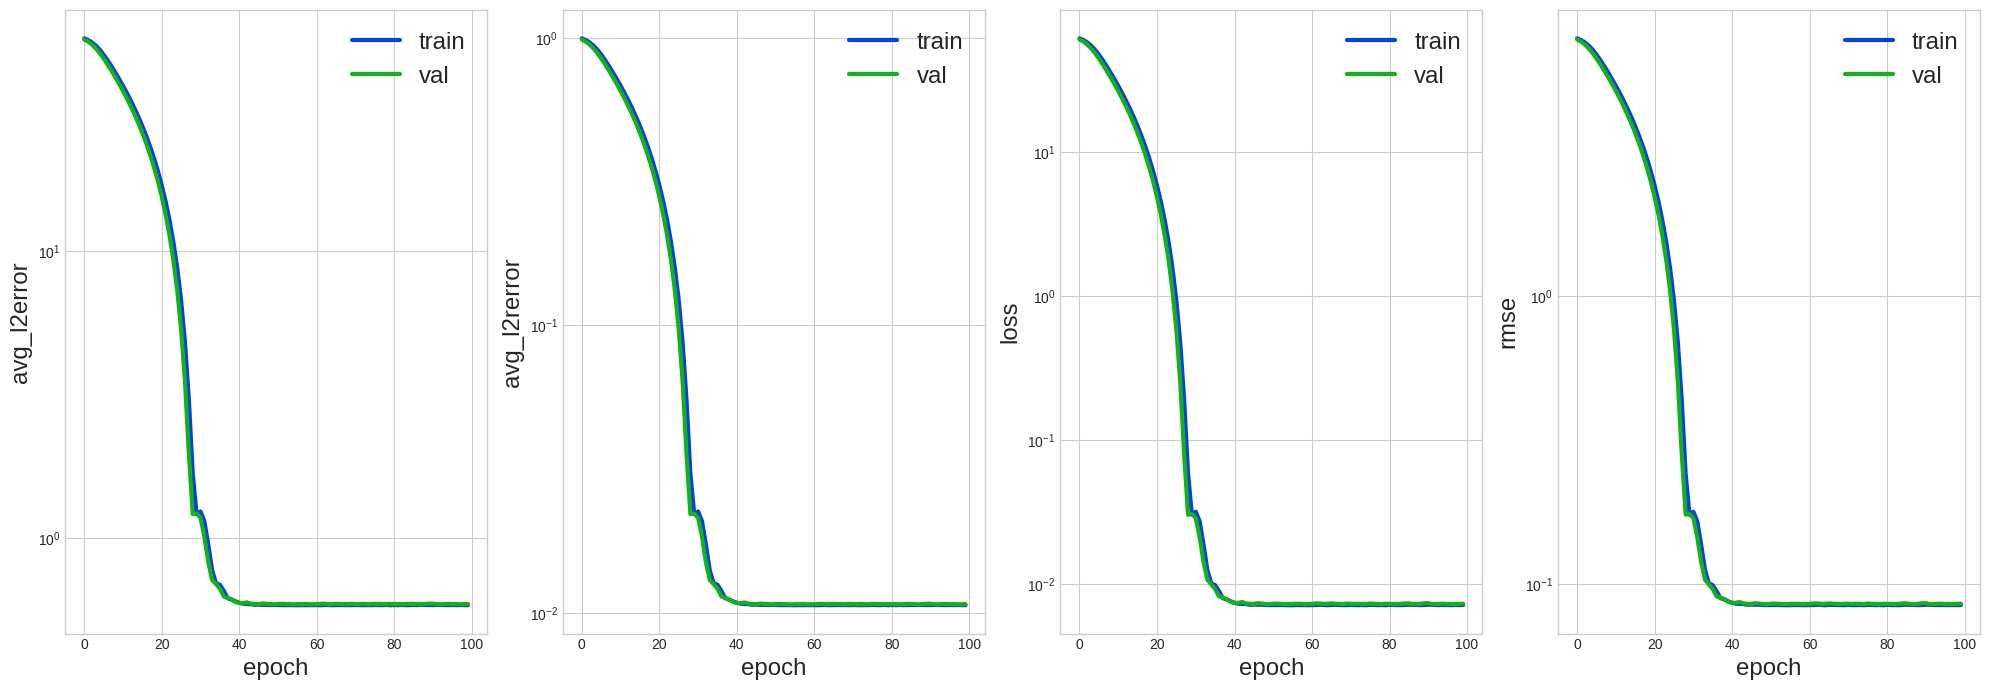

In [14]:
metrics = chonknoris.parse_metrics("%s/%s/csv/metrics.csv"%(save_dir,name))
fig,ax = chonknoris.plot_metrics(metrics,linewidth=LWTHICK,color_train=COLORS[0],color_val=COLORS[1],s0=0)
fig.tight_layout()
metrics.iloc[::max(1,len(metrics)//8)]

In [23]:
lnn_ig = lnn_ig.to(DEVICE) 
with torch.no_grad(), torch.inference_mode():
    outputs_v_hat_sgp_ig_raw_mlp = lnn_ig(inputs_ig_v.to(DEVICE))
outputs_v_hat_sgp_ig_mlp = outputs_v_hat_sgp_ig_raw_mlp*outputs_raw_ig_t_std.to(DEVICE)+outputs_raw_ig_t_mean.to(DEVICE)
print("l2 relative error: %.2e"%(torch.linalg.norm(torch.exp(outputs_v_hat_sgp_ig_mlp)-torch.exp(outputs_raw_ig_v.to(DEVICE)),dim=-1)/torch.linalg.norm(torch.exp(outputs_raw_ig_v.to(DEVICE)),dim=-1)).mean())

l2 relative error: 8.07e-02


### GP

In [16]:
import gc
gc.collect()
torch.cuda.empty_cache()

EPS64 = fastgps.util.EPS64

sgp_ig = fastgps.StandardGP(
    Ns*Nt*Nx,
    data={
        "x": inputs_ig_t.to(DEVICE),
        "y": outputs_ig_t.to(DEVICE).T},
    shape_batch=[Nx*Nx],
    device=DEVICE,
    compile_dist_func=True,
    #scale = 1, 
    shape_scale = [Nx*Nx,1],
    # shape_scale = [1],
    #lengthscales=Ns*Nt*Nx,
    # shape_lengthscales=[1],
    shape_lengthscales=[Ns*Nt*Nx],
    noise=1e-8,
    shape_noise=[Nx*Nx,1],
    # tfs_scale = (lambda x: torch.log(x-EPS64), lambda x: torch.exp(x)+EPS64),
    # tfs_lengthscales = (lambda x: torch.log(x-EPS64), lambda x: torch.exp(x)+EPS64),
    # tfs_noise = (lambda x: torch.log(x-EPS64), lambda x: torch.exp(x)+EPS64),
    # tfs_scale = (lambda x: torch.sqrt(x-EPS64), lambda x: x**2+EPS64),
    # tfs_lengthscales = (lambda x: torch.sqrt(x-EPS64), lambda x: x**2+EPS64),
    # tfs_noise = (lambda x: torch.sqrt(x-EPS64), lambda x: x**2+EPS64),
    # tfs_scale = (lambda x: (x-EPS64)**(1/4), lambda x: x**4+EPS64),
    # tfs_lengthscales = (lambda x: (x-EPS64)**(1/4), lambda x: x**4+EPS64),
    # tfs_noise = (lambda x: (x-EPS64)**(1/4), lambda x: x**4+EPS64),
    # shape_noise=[1],
    requires_grad_noise=True,
    kernel_class="gaussian",
)
for pname,pval in sgp_ig.named_parameters():
    print("%s.shape = %s"%(pname,str(tuple(pval.shape))))
print()
fit_data_sgp_ig = sgp_ig.fit(
    loss_metric = "CV",
    cv_weights = 1/torch.linalg.norm(outputs_ig_t.to(DEVICE),dim=1),
    iterations=50,
    verbose=10,
    store_hists=True,
    stop_crit_wait_iterations=np.inf,
    stop_crit_improvement_threshold=1e-1,
    # lr = 1e-6
    #optimizer = torch.optim.Rprop(sgp_ig.parameters(),lr=1e-1,etas=(1/1000,1001/1000),step_sizes=(0,5))
    )

raw_scale.shape = (49, 1)
raw_lengthscales.shape = (3500,)
raw_noise.shape = (49, 1)
raw_factor_task_kernel.shape = (1, 0)
raw_noise_task_kernel.shape = (1,)

     iter of 5.0e+01 | loss       | term1      | term2     
    ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
            0.00e+00 | 4.40e+04   | nan        | nan       
            1.00e+01 | 2.16e+04   | nan        | nan       
            2.00e+01 | 2.57e+00   | nan        | nan       
            3.00e+01 | 3.02e+00   | nan        | nan       
            4.00e+01 | 3.06e+00   | nan        | nan       
            5.00e+01 | 2.19e+00   | nan        | nan       


In [17]:
outputs_v_hat_sgp_ig_raw = sgp_ig.post_mean(inputs_ig_v.to(DEVICE)).T
outputs_v_hat_sgp_ig = outputs_v_hat_sgp_ig_raw*outputs_raw_ig_t_std.to(DEVICE)+outputs_raw_ig_t_mean.to(DEVICE)
print("l2 relative error: %.2e"%(torch.linalg.norm(torch.exp(outputs_v_hat_sgp_ig)-torch.exp(outputs_raw_ig_v.to(DEVICE)),dim=-1)/torch.linalg.norm(torch.exp(outputs_raw_ig_v.to(DEVICE)),dim=-1)).mean())

l2 relative error: 5.88e-02


dict_keys(['iterations', 'loss_hist', 'scale_hist', 'lengthscales_hist', 'noise_hist', 'task_kernel_hist'])
fit_data_sgp_ig[loss_hist].shape = (51,)
fit_data_sgp_ig[scale_hist].shape = (51, 49, 1)
fit_data_sgp_ig[lengthscales_hist].shape = (51, 3500)
fit_data_sgp_ig[noise_hist].shape = (51, 49, 1)


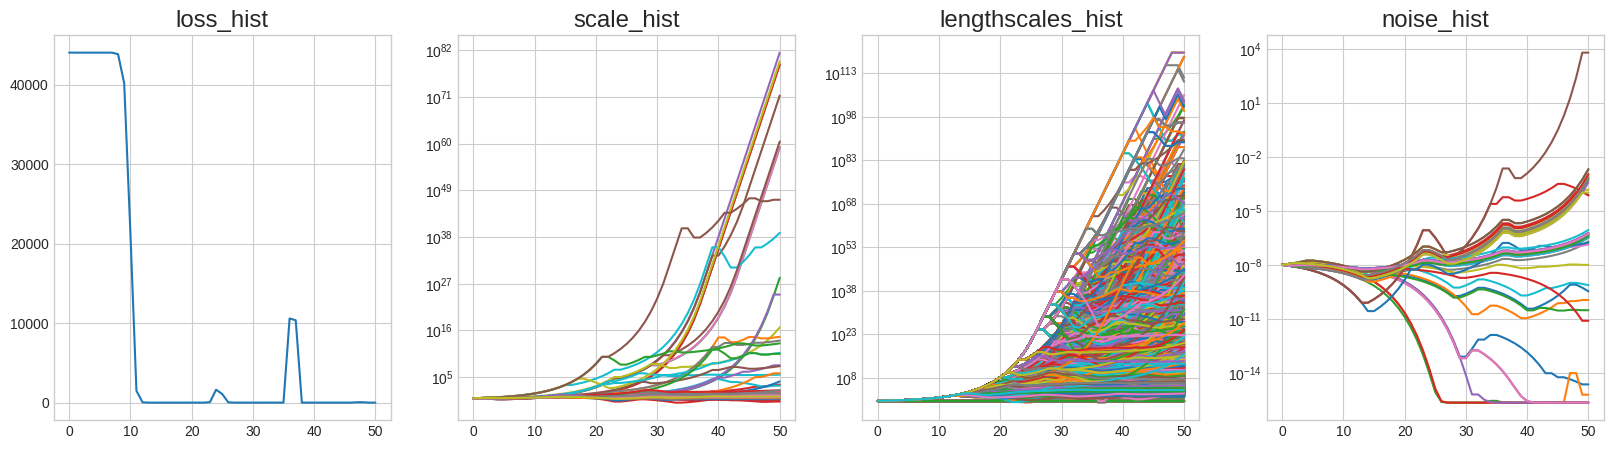

In [31]:
print(fit_data_sgp_ig.keys())
keys_to_plot_log10ed = [
    ('loss_hist',False),
    ('scale_hist',True),
    ('lengthscales_hist',True),
    ('noise_hist',True)]
ncols = len(keys_to_plot_log10ed)
fig,ax = pyplot.subplots(nrows=1,ncols=ncols,figsize=(5*ncols,5))
for i,(key,log10ed) in enumerate(keys_to_plot_log10ed):
    print("fit_data_sgp_ig[%s].shape = %s"%(key,str(tuple(fit_data_sgp_ig[key].shape))))
    if key in ["noise_hist","scale_hist"] and fit_data_sgp_ig[key].ndim==3:
        ax[i].plot(torch.arange(fit_data_sgp_ig[key].size(0)),fit_data_sgp_ig[key][:,:,0])
    else:
        ax[i].plot(torch.arange(fit_data_sgp_ig[key].size(0)),fit_data_sgp_ig[key])
    ax[i].set_title(key,fontsize="xx-large")
    if log10ed: ax[i].set_yscale('log',base=10)

## Dataloader

In [ ]:
M = data["vs"].size(1) # total number of iterations
print("M = %d"%M)
# Midxs = torch.arange(10)
# Midxs = torch.arange(10,15)
# Midxs = torch.tensor([1,2,4,7,11,16,22,29,37])
Midxs = torch.linspace(1,29,steps=10,dtype=int)
# Midxs = torch.linspace(1,39,steps=20,dtype=int)
# Midxs = torch.linspace(1,74,steps=25,dtype=int)
# Midxs = torch.linspace(1,29,steps=10,dtype=int)
# Midxs = torch.linspace(1,29,steps=5,dtype=int)
# Midxs = torch.linspace(1,9,steps=5,dtype=int)
print("Midxs = %s"%str(Midxs.numpy()))
print("len(Midxs) = %d"%len(Midxs))
assert (Midxs<(M-1)).all(), "Midxs must be less than M-1=%d"%(M-1)
outdir_chonknoris = outdir+"/MODELS_L"
if not os.path.isdir(outdir_chonknoris): os.mkdir(outdir_chonknoris)

M = 51
Midxs = [ 1  4  7 10 13 16 19 22 25 29]
len(Midxs) = 10


In [20]:
import gc
gc.collect()
torch.cuda.empty_cache()
_vs = data["vs"][:,Midxs]
vs_t = _vs[data["tidxs"]]
vs_v = _vs[data["vidxs"]]
_relaxations = data["relaxations"][:,Midxs+1]
relaxations_t = _relaxations[data["tidxs"]]
relaxations_v = _relaxations[data["vidxs"]]
_wavefield_full = torch.tile(data["wavefield"][:,None,:,:,:],(1,len(Midxs),1,1,1))
wavefield_full_t = _wavefield_full[data["tidxs"]]
wavefield_full_v = _wavefield_full[data["vidxs"]]
_eyeNx2 = torch.eye(Nx**2,device=DEVICE)
_Linvs = data["Linvs"][:,Midxs]
_L = torch.linalg.solve_triangular(_Linvs.to(DEVICE),_eyeNx2,upper=False).cpu()
# common_relaxation = 1e-5
# Theta = (torch.einsum("rijk,rilk->rijl",_L,_L)-_relaxations[:,:,None,None].to(DEVICE))*_eyeNx2+common_relaxation*_eyeNx2
# _L = torch.linalg.cholesky(Theta).cpu()
# _Linvs = data["Linvs"][:,Midxs]
# Linvs_t = _Linvs[data["tidxs"]]
# Linvs_v = _Linvs[data["vidxs"]]
# L_t = torch.linalg.solve_triangular(Linvs_t.to(DEVICE),_eyeNx2,upper=False).to("cpu")-relaxations_t[...,None,None]
# L_v = torch.linalg.solve_triangular(Linvs_v.to(DEVICE),_eyeNx2,upper=False).to("cpu")-relaxations_v[...,None,None]
# Theta_t = Theta[data["tidxs"]]
# Theta_v = Theta[data["vidxs"]]
#_L = data["Linvs"][:,Midxs]
L_t = _L[data["tidxs"]]
L_v = _L[data["vidxs"]]
#JtF_t = torch.einsum("rijk,rik->rij",L_t,torch.einsum("rikj,rik->rij",L_t,(vs_t[:,1:]-vs_t[:,:-1]).flatten(start_dim=-2)))
#JtF_v = torch.einsum("rijk,rik->rij",L_v,torch.einsum("rikj,rik->rij",L_v,(vs_v[:,1:]-vs_v[:,:-1]).flatten(start_dim=-2)))
_updated = data["updated"][:,Midxs]
updated_t = _updated[data["tidxs"]]
updated_v = _updated[data["vidxs"]]

In [21]:
print("vs_t.shape = %s"%str(tuple(vs_t.shape)))
print("vs_v.shape = %s"%str(tuple(vs_v.shape)))
print("relaxations_t.shape = %s"%str(tuple(relaxations_t.shape)))
print("relaxations_v.shape = %s"%str(tuple(relaxations_v.shape)))
print("wavefield_full_t.shape = %s"%str(tuple(wavefield_full_t.shape)))
print("wavefield_full_v.shape = %s"%str(tuple(wavefield_full_v.shape)))
# print("Linvs_t.shape = %s"%str(tuple(Linvs_t.shape)))
# print("Linvs_v.shape = %s"%str(tuple(Linvs_v.shape)))
# print("Theta_t.shape = %s"%str(tuple(Theta_t.shape)))
# print("Theta_v.shape = %s"%str(tuple(Theta_v.shape)))
print("L_t.shape = %s"%str(tuple(L_t.shape)))
print("L_v.shape = %s"%str(tuple(L_v.shape)))
# print("JtF_t.shape = %s"%str(tuple(JtF_t.shape)))
# print("JtF_v.shape = %s"%str(tuple(JtF_v.shape)))
print("updated_t.shape = %s"%str(tuple(updated_t.shape)))
print("updated_v.shape = %s"%str(tuple(updated_v.shape)))

vs_t.shape = (800, 10, 7, 7)
vs_v.shape = (200, 10, 7, 7)
relaxations_t.shape = (800, 10)
relaxations_v.shape = (200, 10)
wavefield_full_t.shape = (800, 10, 5, 100, 7)
wavefield_full_v.shape = (200, 10, 5, 100, 7)
L_t.shape = (800, 10, 49, 49)
L_v.shape = (200, 10, 49, 49)
updated_t.shape = (800, 10)
updated_v.shape = (200, 10)


In [74]:
lti0,lti1 = torch.tril_indices(Nx**2,Nx**2)
inputs_raw_t = torch.cat([torch.log(relaxations_t[updated_t][:,None]),torch.log(vs_t[updated_t].flatten(start_dim=1)),wavefield_full_t[updated_t].flatten(start_dim=1)],dim=-1)
inputs_raw_v = torch.cat([torch.log(relaxations_v[updated_v][:,None]),torch.log(vs_v[updated_v].flatten(start_dim=1)),wavefield_full_v[updated_v].flatten(start_dim=1)],dim=-1)
print("inputs_raw_t.shape = %s"%str(tuple(inputs_raw_t.shape)))
print("inputs_raw_v.shape = %s"%str(tuple(inputs_raw_v.shape)))
inputs_raw_t_mean = inputs_raw_t.mean(0).to(DEVICE)
inputs_raw_t_std = inputs_raw_t.std(0).to(DEVICE)
inputs_raw_t_std[inputs_raw_t_std==0] = 1
inputs_raw_t_mean[:] = 0 # UNCOMMNET TO AVOID INPUT NORMALIZATION 
inputs_raw_t_std[:] = 1 # UNCOMMNET TO AVOID INPUT NORMALIZATION
inputs_t = (inputs_raw_t-inputs_raw_t_mean.to("cpu"))/inputs_raw_t_std.to("cpu")
inputs_v = (inputs_raw_v-inputs_raw_t_mean.to("cpu"))/inputs_raw_t_std.to("cpu")
print("inputs_t.shape = %s"%str(tuple(inputs_raw_t.shape)))
print("inputs_v.shape = %s"%str(tuple(inputs_raw_v.shape)))
# outputs_t = (vs_t[:,1:]-vs_t[:,:-1])[updated_t].flatten(start_dim=1)
# outputs_v = (vs_v[:,1:]-vs_v[:,:-1])[updated_v].flatten(start_dim=1)
L_t_u = L_t[updated_t]
L_v_u = L_v[updated_v]
_Nxr2 = torch.arange(Nx*Nx)
# L_t_u[:,_Nxr2,_Nxr2] = torch.log(L_t_u[:,_Nxr2,_Nxr2])
# L_v_u[:,_Nxr2,_Nxr2] = torch.log(L_v_u[:,_Nxr2,_Nxr2])
outputs_raw_t = L_t_u[:,lti0,lti1].clone()
outputs_raw_v = L_v_u[:,lti0,lti1].clone()
outputs_raw_t_mean = outputs_raw_t.mean(0).to(DEVICE)
outputs_raw_t_std = outputs_raw_t.std(0).to(DEVICE)
outputs_raw_t_std[outputs_raw_t_std==0] = 1
outputs_raw_t_mean[:] = 0 # UNCOMMNET TO AVOID OUTPUT NORMALIZATION
outputs_raw_t_std[:] = 1 # UNCOMMNET TO AVOID OUTPUT NORMALIZATION
outputs_t = (outputs_raw_t-outputs_raw_t_mean.to("cpu"))/outputs_raw_t_std.to("cpu")
outputs_v = (outputs_raw_v-outputs_raw_t_mean.to("cpu"))/outputs_raw_t_std.to("cpu")
ds_t = chonknoris.DatasetClassic(inputs_t,outputs_t)
ds_v = chonknoris.DatasetClassic(inputs_v,outputs_v)
print("outputs_t.shape = %s"%str(tuple(outputs_t.shape)))
print("outputs_v.shape = %s"%str(tuple(outputs_v.shape)))
print("len(ds_t) = %d"%len(ds_t))
print("len(ds_v) = %d"%len(ds_v))

inputs_raw_t.shape = (7034, 3550)
inputs_raw_v.shape = (1769, 3550)
inputs_t.shape = (7034, 3550)
inputs_v.shape = (1769, 3550)
outputs_t.shape = (7034, 1225)
outputs_v.shape = (1769, 1225)
len(ds_t) = 7034
len(ds_v) = 1769


## MLP

In [75]:
import gc
gc.collect()
torch.cuda.empty_cache()

save_dir = outdir_chonknoris
name = "MLP"
resume = True

dl_mlp_t = torch.utils.data.DataLoader(ds_t,batch_size=2**8,collate_fn=tuple,shuffle=True)
dl_mlp_v = torch.utils.data.DataLoader(ds_v,batch_size=len(ds_v),collate_fn=tuple,shuffle=False)
print("len(dl_mlp_t) = %d"%len(dl_mlp_t))
print("len(dl_mlp_v) = %d"%len(dl_mlp_v))
print()

nn = chonknoris.MLP(mlp_layer_nodes=[1+Nx**2+Ns*Nt*Nx]+3*[250]+[Nx**2*(1+Nx**2)//2],activation_function=torch.nn.Tanh())
#nn = chonknoris.MLP(mlp_layer_nodes=[1+Nx**2+Ns*Nt*Nx]+5*[1000]+[Nx**2*(1+Nx**2)//2],activation_function=torch.nn.Tanh())
lnn = chonknoris.LightningNN(nn,lr=1e-2,use_l2rerror_loss=True).to(DEVICE)
print(lnn)

csv_logger = lightning.pytorch.loggers.CSVLogger(save_dir=save_dir,name=name,version='csv')
trainer = lightning.Trainer(
    max_epochs = 25,
    logger = [csv_logger],
    #accelerator = "cpu",
    #limit_train_batches=2**10,
    #log_every_n_steps = 1e10,
    enable_progress_bar = True,
    #num_sanity_val_steps = 0,
    #gradient_clip_val = 1.0,
    #gradient_clip_algorithm = "norm",
  )
trainer.fit(
    model = lnn, 
    train_dataloaders = dl_mlp_t,
    val_dataloaders = dl_mlp_v,
    ckpt_path = sorted(glob.glob("./%s/%s/csv/checkpoints/*.ckpt"%(save_dir,name)),key=os.path.getmtime)[-1] if resume else None,
)


Trainer will use only 1 of 7 GPUs because it is running inside an interactive / notebook environment. You may try to set `Trainer(devices=7)` but please note that multi-GPU inside interactive / notebook environments is considered experimental and unstable. Your mileage may vary.
Using default `ModelCheckpoint`. Consider installing `litmodels` package to enable `LitModelCheckpoint` for automatic upload to the Lightning model registry.


GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
/home/aleksei.sorokin/miniconda3/envs/dno/lib/python3.13/site-packages/lightning/fabric/loggers/csv_logs.py:268: Experiment logs directory ./data/RES7/Style_B/MODELS_L/MLP/csv exists and is not empty. Previous log files in this directory will be deleted when the new ones are saved!
/home/aleksei.sorokin/miniconda3/envs/dno/lib/python3.13/site-packages/lightning/pytorch/callbacks/model_checkpoint.py:654: Checkpoint directory ./data/RES7/Style_B/MODELS_L/MLP/csv/checkpoints exists and is not empty.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1,2,3,4,5,6]

  | Name | Type | Params | Mode 
--------------------------------------
0 | nn   | MLP  | 1.3 M  | train
--------------------------------------
1.3 M     Trainable params
0         Non-trainable params
1.3 M     Total params
5.283     Total estimated model params size (MB)
7         Modules in train mode
0         Modules in 

len(dl_mlp_t) = 28
len(dl_mlp_v) = 1

LightningNN(
  (nn): MLP(
    (nn_sequential): Sequential(
      (0): Linear(in_features=3550, out_features=250, bias=True)
      (1): Tanh()
      (2): Linear(in_features=250, out_features=250, bias=True)
      (3): Tanh()
      (4): Linear(in_features=250, out_features=250, bias=True)
      (5): Tanh()
      (6): Linear(in_features=250, out_features=1225, bias=True)
    )
  )
)
                                                                            

/home/aleksei.sorokin/miniconda3/envs/dno/lib/python3.13/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:425: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=255` in the `DataLoader` to improve performance.
/home/aleksei.sorokin/miniconda3/envs/dno/lib/python3.13/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:425: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=255` in the `DataLoader` to improve performance.
/home/aleksei.sorokin/miniconda3/envs/dno/lib/python3.13/site-packages/lightning/pytorch/loops/fit_loop.py:310: The number of training batches (28) is smaller than the logging interval Trainer(log_every_n_steps=50). Set a lower value for log_every_n_steps if you want to see logs for the training epoch.


Epoch 24: 100%|██████████| 28/28 [00:00<00:00, 46.77it/s, v_num=csv, val_loss=22.90, val_rmse=4.790, val_avg_l2error=164.0, val_avg_l2rerror=0.259, train_loss=21.80, train_rmse=4.670, train_avg_l2error=161.0, train_avg_l2rerror=0.252]

`Trainer.fit` stopped: `max_epochs=25` reached.


Epoch 24: 100%|██████████| 28/28 [00:01<00:00, 23.02it/s, v_num=csv, val_loss=22.90, val_rmse=4.790, val_avg_l2error=164.0, val_avg_l2rerror=0.259, train_loss=21.80, train_rmse=4.670, train_avg_l2error=161.0, train_avg_l2rerror=0.252]


,train_avg_l2error,val_avg_l2error,train_avg_l2rerror,val_avg_l2rerror,train_loss,val_loss,train_rmse,val_rmse
0,492.943754,307.137067,0.757389,0.475126,209.540801,78.725836,14.200746,8.872758
3,160.879977,164.322594,0.251659,0.259832,21.833911,22.968356,4.672276,4.792531
6,160.741023,164.308965,0.251523,0.259542,21.809726,22.904714,4.669618,4.785887
9,160.775020,164.122358,0.251579,0.259453,21.817377,22.901700,4.670461,4.785572
12,160.723903,164.251908,0.251499,0.259458,21.804964,22.905684,4.669275,4.785988
15,160.782944,164.423768,0.251506,0.259852,21.814214,22.983573,4.670286,4.794119
18,160.703032,164.290624,0.251501,0.259253,21.800731,22.896053,4.668815,4.784982
21,160.834661,164.303375,0.251654,0.259259,21.834992,22.854414,4.672364,4.780629
24,160.757416,164.260587,0.251635,0.259408,21.823035,22.896506,4.671221,4.785029


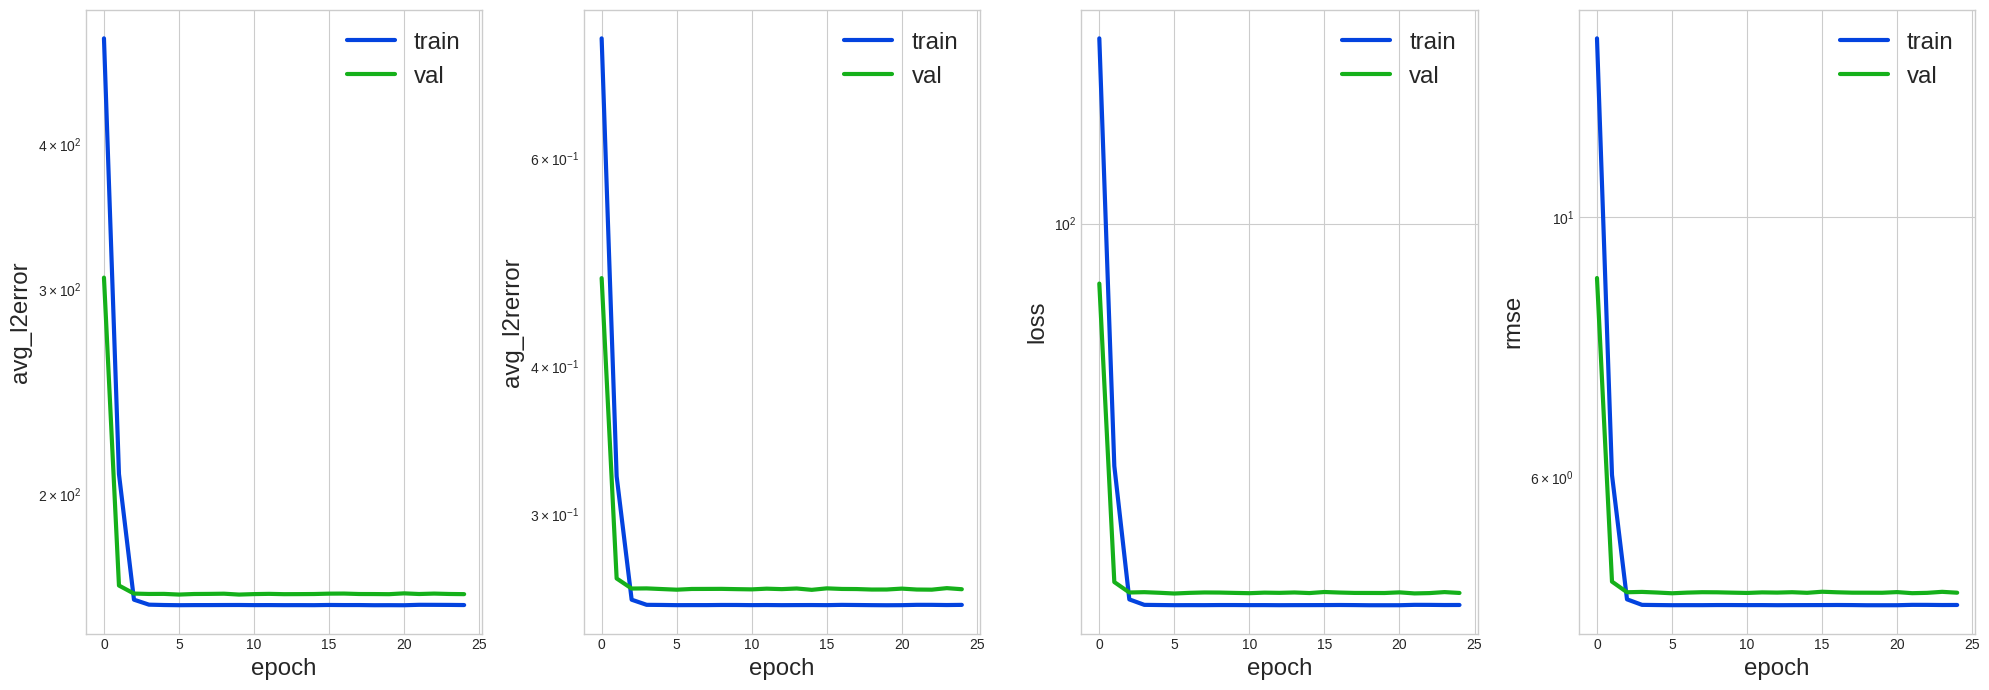

In [76]:
metrics = chonknoris.parse_metrics("%s/%s/csv/metrics.csv"%(save_dir,name))
fig,ax = chonknoris.plot_metrics(metrics,linewidth=LWTHICK,color_train=COLORS[0],color_val=COLORS[1],s0=0)
fig.tight_layout()
metrics.iloc[::max(1,len(metrics)//8)]

In [77]:
lnn = lnn.to(DEVICE) 
with torch.no_grad(), torch.inference_mode():
    outputs_v_hat_sgp_raw_mlp = lnn(inputs_v.to(DEVICE))
print("l2 relative error: %.2e"%(torch.linalg.norm(outputs_v_hat_sgp_raw_mlp-outputs_v.to(DEVICE),dim=-1)/torch.linalg.norm(outputs_v.to(DEVICE),dim=-1)).mean())

l2 relative error: 2.59e-01


## GPR

In [78]:
import gc
gc.collect()
torch.cuda.empty_cache()
sgp = fastgps.StandardGP(
    1+Nx*Nx+Ns*Nt*Nx,
    data={"x":inputs_t.to(DEVICE),"y":outputs_t.T.to(DEVICE)},
    shape_batch=[Nx*Nx*(1+Nx*Nx)//2],
    device=DEVICE,
    #shape_scale = [Nx*Nx*(1+Nx*Nx)//2,1],
    #lengthscales=1+Nx*Nx+Ns*Nt*Nx,
    #shape_lengthscales=[1],
    shape_lengthscales=[1+Nx*Nx+Ns*Nt*Nx],
    noise = 1e-8,
    requires_grad_noise=True,
    compile_dist_func=True,
    kernel_class="matern52",
    # tfs_scale = (lambda x: torch.log(x-EPS64), lambda x: torch.exp(x)+EPS64),
    # tfs_lengthscales = (lambda x: torch.log(x-EPS64), lambda x: torch.exp(x)+EPS64),
    # tfs_noise = (lambda x: torch.log(x-EPS64), lambda x: torch.exp(x)+EPS64),
    # tfs_scale = (lambda x: torch.sqrt(x-EPS64), lambda x: x**2+EPS64),
    # tfs_lengthscales = (lambda x: torch.sqrt(x-EPS64), lambda x: x**2+EPS64),
    # tfs_noise = (lambda x: torch.sqrt(x-EPS64), lambda x: x**2+EPS64),
    # tfs_scale = (lambda x: (x-EPS64)**(1/4), lambda x: x**4+EPS64),
    # tfs_lengthscales = (lambda x: (x-EPS64)**(1/4), lambda x: x**4+EPS64),
    # tfs_noise = (lambda x: (x-EPS64)**(1/4), lambda x: x**4+EPS64),
)
for pname,pval in sgp.named_parameters():
    print("%s.shape = %s"%(pname,str(tuple(pval.shape))))
print()
fit_data_sgp = sgp.fit(
    loss_metric = "CV",
    cv_weights = 1/torch.linalg.norm(outputs_t.to(DEVICE),dim=1),
    #cv_weights = torch.log10(1/relaxations_t[updated_t]).to(DEVICE)**4,
    # cv_weights = torch.log10(relaxations_t[updated_t].to(DEVICE))/torch.linalg.norm(outputs_t.to(DEVICE),dim=1),
    iterations = 50,
    verbose = 1,
    store_hists = True,
    stop_crit_wait_iterations = np.inf,
    #stop_crit_improvement_threshold = 1e-1,
    #lr = 1e0,
    #optimizer=torch.optim.Rprop(sgp.parameters(),lr=1e0),#,etas=(0.5,1.2),step_sizes=(0,10)),
    #optimizer=torch.optim.Adam(sgp.parameters(),lr=1e0,amsgrad=True),#,lr=5e-2),
    )

raw_scale.shape = (1,)
raw_lengthscales.shape = (3550,)
raw_noise.shape = (1,)
raw_factor_task_kernel.shape = (1, 0)
raw_noise_task_kernel.shape = (1,)

     iter of 5.0e+01 | loss       | term1      | term2     
    ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
            0.00e+00 | 5.61e+05   | nan        | nan       
            1.00e+00 | 4.24e+05   | nan        | nan       
            2.00e+00 | 2.99e+05   | nan        | nan       
            3.00e+00 | 1.97e+05   | nan        | nan       
            4.00e+00 | 1.21e+05   | nan        | nan       
            5.00e+00 | 6.98e+04   | nan        | nan       
            6.00e+00 | 3.79e+04   | nan        | nan       
            7.00e+00 | 2.20e+04   | nan        | nan       
            8.00e+00 | 1.60e+04   | nan        | nan       
            9.00e+00 | 1.24e+04   | nan        | nan       
            1.00e+01 | 7.49e+03   | nan        | nan       
            1.10e+01 | 3.04e+03   | nan        | nan       
       

In [82]:
outputs_v_hat_sgp = sgp.post_mean(inputs_v.to(DEVICE)).T
l2rerrors_v = torch.linalg.norm(outputs_v_hat_sgp-outputs_v.to(DEVICE),dim=-1)/torch.linalg.norm(outputs_v.to(DEVICE),dim=-1)
print("l2 relative error: %.2e"%torch.mean(l2rerrors_v))

l2 relative error: 3.59e-02


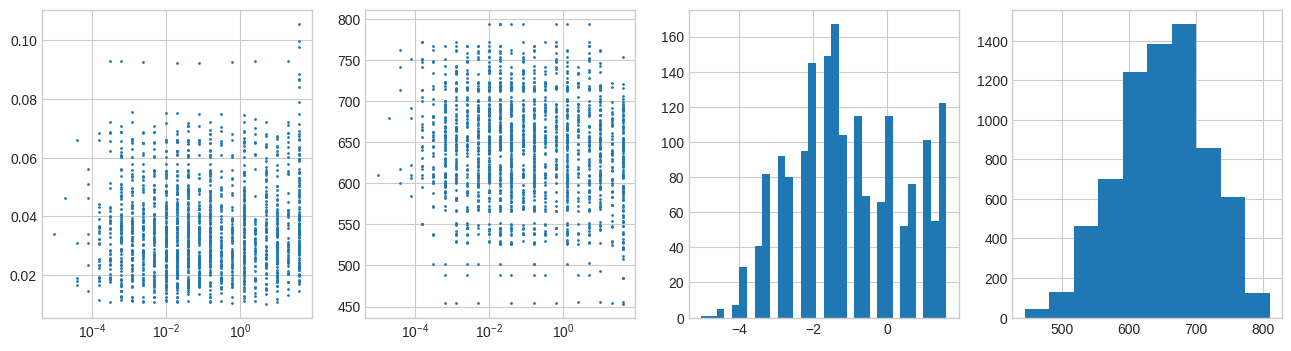

In [83]:
fig,ax = pyplot.subplots(nrows=1,ncols=4,figsize=(16,4))
ax[0].scatter(relaxations_v[updated_v].cpu(),l2rerrors_v.cpu(),s=1)
ax[0].set_xscale("log",base=10)
ax[1].scatter(relaxations_v[updated_v].cpu(),torch.linalg.norm(outputs_v.to(DEVICE),dim=1).cpu(),s=1)
ax[1].set_xscale("log",base=10)
ax[2].hist(torch.log10(relaxations_v[updated_v].cpu()),bins=32);
ax[3].hist(torch.linalg.norm(outputs_t.to(DEVICE),dim=1).cpu());

dict_keys(['iterations', 'loss_hist', 'scale_hist', 'lengthscales_hist', 'noise_hist', 'task_kernel_hist'])


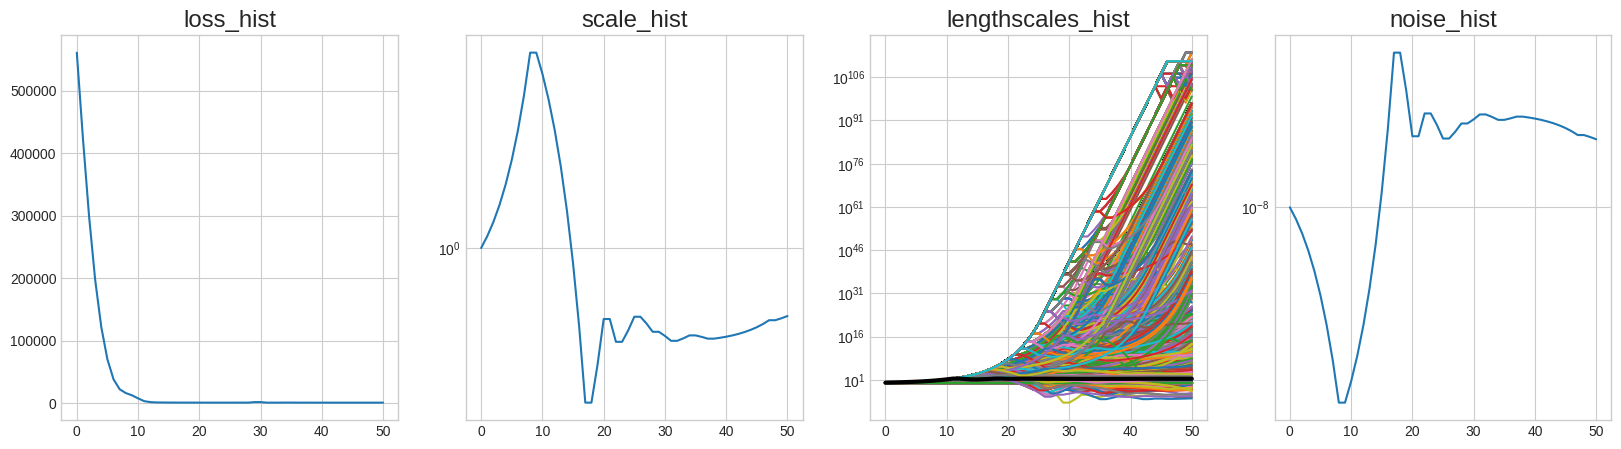

In [84]:
print(fit_data_sgp.keys())
keys_to_plot_log10ed = [
    ('loss_hist',False),
    ('scale_hist',True),
    ('lengthscales_hist',True),
    ('noise_hist',True)]
ncols = len(keys_to_plot_log10ed)
fig,ax = pyplot.subplots(nrows=1,ncols=ncols,figsize=(5*ncols,5))
for i,(key,log10ed) in enumerate(keys_to_plot_log10ed):
    ax[i].plot(torch.arange(fit_data_sgp[key].size(0)),fit_data_sgp[key])
    ax[i].set_title(key,fontsize="xx-large")
    if log10ed: ax[i].set_yscale('log',base=10)
ax[2].plot(torch.arange(fit_data_sgp["lengthscales_hist"].size(0)),fit_data_sgp["lengthscales_hist"][:,0],color="k",linewidth=3);

## Inference

In [85]:
#lmodel = lnn.to(DEVICE)
lmodel = lambda x: sgp.post_mean(x).T
def predict(relaxations, logv, w, JtF):
    assert relaxations.ndim==1 and logv.ndim==2 and relaxations.size(0)==logv.size(0)==w.size(0)
    inputs_raw = torch.cat([torch.log(relaxations[:,None]),logv,w.flatten(start_dim=1)],dim=-1)
    inputs = (inputs_raw-inputs_raw_t_mean)/inputs_raw_t_std
    L = torch.zeros((logv.size(0),Nx**2,Nx**2),device=logv.device)
    with torch.no_grad(), torch.inference_mode(), gpytorch.settings.fast_pred_var():
        L_raw_flat = lmodel(inputs)
    L_flat = L_raw_flat*outputs_raw_t_std+outputs_raw_t_mean
    L[:,lti0,lti1] = L_flat
    #L[:,_Nxr2,_Nxr2] = torch.exp(L[:,_Nxr2,_Nxr2])
    success = torch.ones(logv.size(0),dtype=bool,device=logv.device)
    # delta_try = torch.einsum("rji,rj->ri",L,torch.einsum("rij,rj->ri",L,JtF))
    delta_try = torch.cholesky_solve(JtF[success,:,None],L[success],upper=False)[...,0]
    return delta_try,success
# def predict(relaxations, v, w, JtF):
#     assert relaxations.ndim==1 and v.ndim==2 and relaxations.size(0)==v.size(0)==w.size(0)
#     inputs_raw = torch.cat([torch.log(relaxations)[:,None],v,w.flatten(start_dim=1)],dim=-1)
#     #inputs_raw = torch.cat([v,w.flatten(start_dim=1)],dim=-1)
#     inputs = (inputs_raw-inputs_raw_t_mean)/inputs_raw_t_std
#     L =  torch.empty((v.size(0),Nx**2,Nx**2),device=v.device)
#     with torch.no_grad(), torch.inference_mode(), gpytorch.settings.fast_pred_var():
#         L_flat = lmodel(inputs)
#     L[:,lti0,lti1] = L_flat
#     # Theta = torch.einsum("rik,rlk->ril",L,L)-common_relaxation*_eyeNx2+relaxations[:,None,None]*_eyeNx2
#     # L,fails = torch.linalg.cholesky_ex(Theta,upper=False)
#     # success = fails==0
#     success = torch.ones(v.size(0),dtype=bool,device=v.device)
#     delta_try = torch.cholesky_solve(JtF[success,:,None],L[success],upper=False)[...,0]
#     return delta_try,success
R_infer = 25
num_newton_iter_infer = 500
vref = data["velocity"][data["vidxs"]][:R_infer].to(DEVICE)
w = data["wavefield"][data["vidxs"]][:R_infer].to(DEVICE)
#v0 = data["vs"][data["vidxs"]][:R_infer,0].to(DEVICE)
#v0 = data["vs"][data["vidxs"]][:R_infer,10].to(DEVICE)
v0 = torch.exp(outputs_v_hat_sgp_ig[:R_infer]).reshape((R_infer,Nx,Nx))
_,data_infer = fwi_gn_solver(p,w,v0,Thetainv_v=Thetainv_v.to(DEVICE),Thetainv_w=Thetainv_w.to(DEVICE),num_newton_iter=num_newton_iter_infer,vref=vref,predict=predict,print_rmse_flow=False,
                             relaxation=1e1,
                             lr=1,
                             wiggle_factors_relaxation=(1/2,2),
                             wiggle_factors_lr=(1/2,2),
                             range_relaxations=(0,1e-3),
                             range_lrs = (0,100))
#_,data_infer = fwi_gn_solver(p,w,v0,num_newton_iter=num_newton_iter_infer,relaxation=4.8e-8,lr=1,vref=vref,use_pca=False,predict=predict,print_rmse_flow=False,wiggle_factor_relaxation=2,wiggle_factor_lr=2)


    iter of 500    | time      | RMSE                                                             | L2 relative error                                   | relaxations                                         | lrs                                                 |
                   |           | 5%           median       mean         95%          finite %     | 5%           median       mean         95%          | 5%           median       mean         95%          | 5%           median       mean         95%          |
    -----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
    0              | 2.65e+01  | 3.04e+00     6.07e+00     6.75e+00     1.39e+01     100.0        | 3.37e-02     5.30e-02     5.70e-02     8.47e-02     | 1.00e+01     1.00e+01     1.00e+01     1.00e+01     | 1.00e+

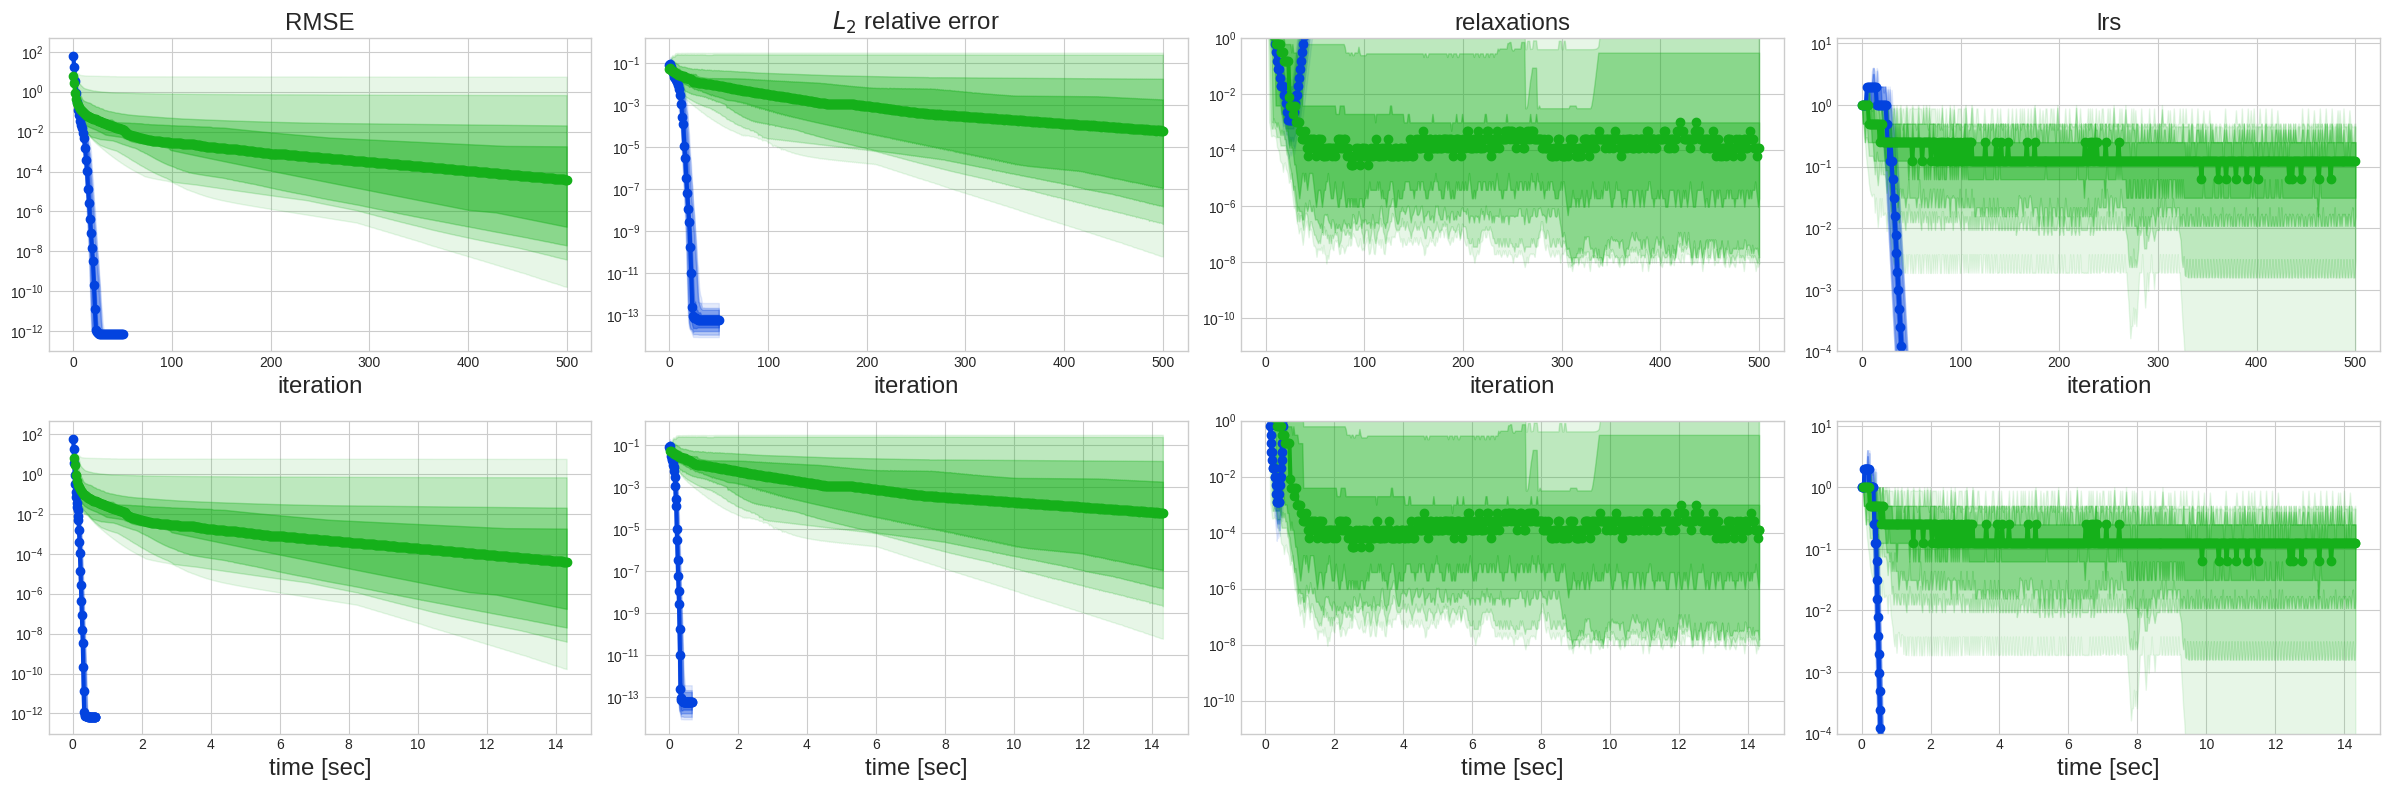

In [87]:
fig,ax = chonknoris.plot_band_strand(
    data = [
        [
            [
                (None,data["rmses"][data["vidxs"]][:R_infer,:num_newton_iter_infer],None),
                (None,data_infer["rmses"],None)
            ],
            [
                (None,data["l2rerrors"][data["vidxs"]][:R_infer,:num_newton_iter_infer],None),
                (None,data_infer["l2rerrors"],None)],
            [
                (None,data["relaxations"][data["vidxs"]][:R_infer,:num_newton_iter_infer],None),
                (None,data_infer["relaxations"],None)],
            [
                (None,data["lrs"][data["vidxs"]][:R_infer,:num_newton_iter_infer],None),
                (None,data_infer["lrs"],None)],

        ],
        [
            [
                (data["times"][:num_newton_iter_infer].cumsum(0),data["rmses"][data["vidxs"]][:R_infer,:num_newton_iter_infer],None),
                ((data_infer["times"]/R_infer).cumsum(0),data_infer["rmses"],None)],
            [
                (data["times"][:num_newton_iter_infer].cumsum(0),data["l2rerrors"][data["vidxs"]][:R_infer,:num_newton_iter_infer],None),
                ((data_infer["times"]/R_infer).cumsum(0),data_infer["l2rerrors"],None)],
            [
                (data["times"][:num_newton_iter_infer].cumsum(0),data["relaxations"][data["vidxs"]][:R_infer,:num_newton_iter_infer],None),
                ((data_infer["times"]/R_infer).cumsum(0),data_infer["relaxations"],None)],
            [
                (data["times"][:num_newton_iter_infer].cumsum(0),data["lrs"][data["vidxs"]][:R_infer,:num_newton_iter_infer],None),
                ((data_infer["times"]/R_infer).cumsum(0),data_infer["lrs"],None)],

        ],
    ],
    sharex = False,
    titles = [["RMSE",r"$L_2$ relative error","relaxations","lrs"],[None,None,None,None]],
    xlabels = [["iteration"],["time [sec]"]],
    xlogscale = False,
    colors = COLORS,
    ylogscale = True,
    fsx=4,fsy=6)
for i in range(2):
    ax[i,2].set_ylim([ax[i,2].get_ylim()[0],1])
    ax[i,3].set_ylim([1e-4,ax[i,3].get_ylim()[1]])
fig.tight_layout()

tensor([0.0530, 0.0624, 0.0746, 0.0530, 0.0639])
tensor([1.4133e-02, 5.1190e-04, 1.0214e-05, 3.9537e-13, 1.4593e-05])


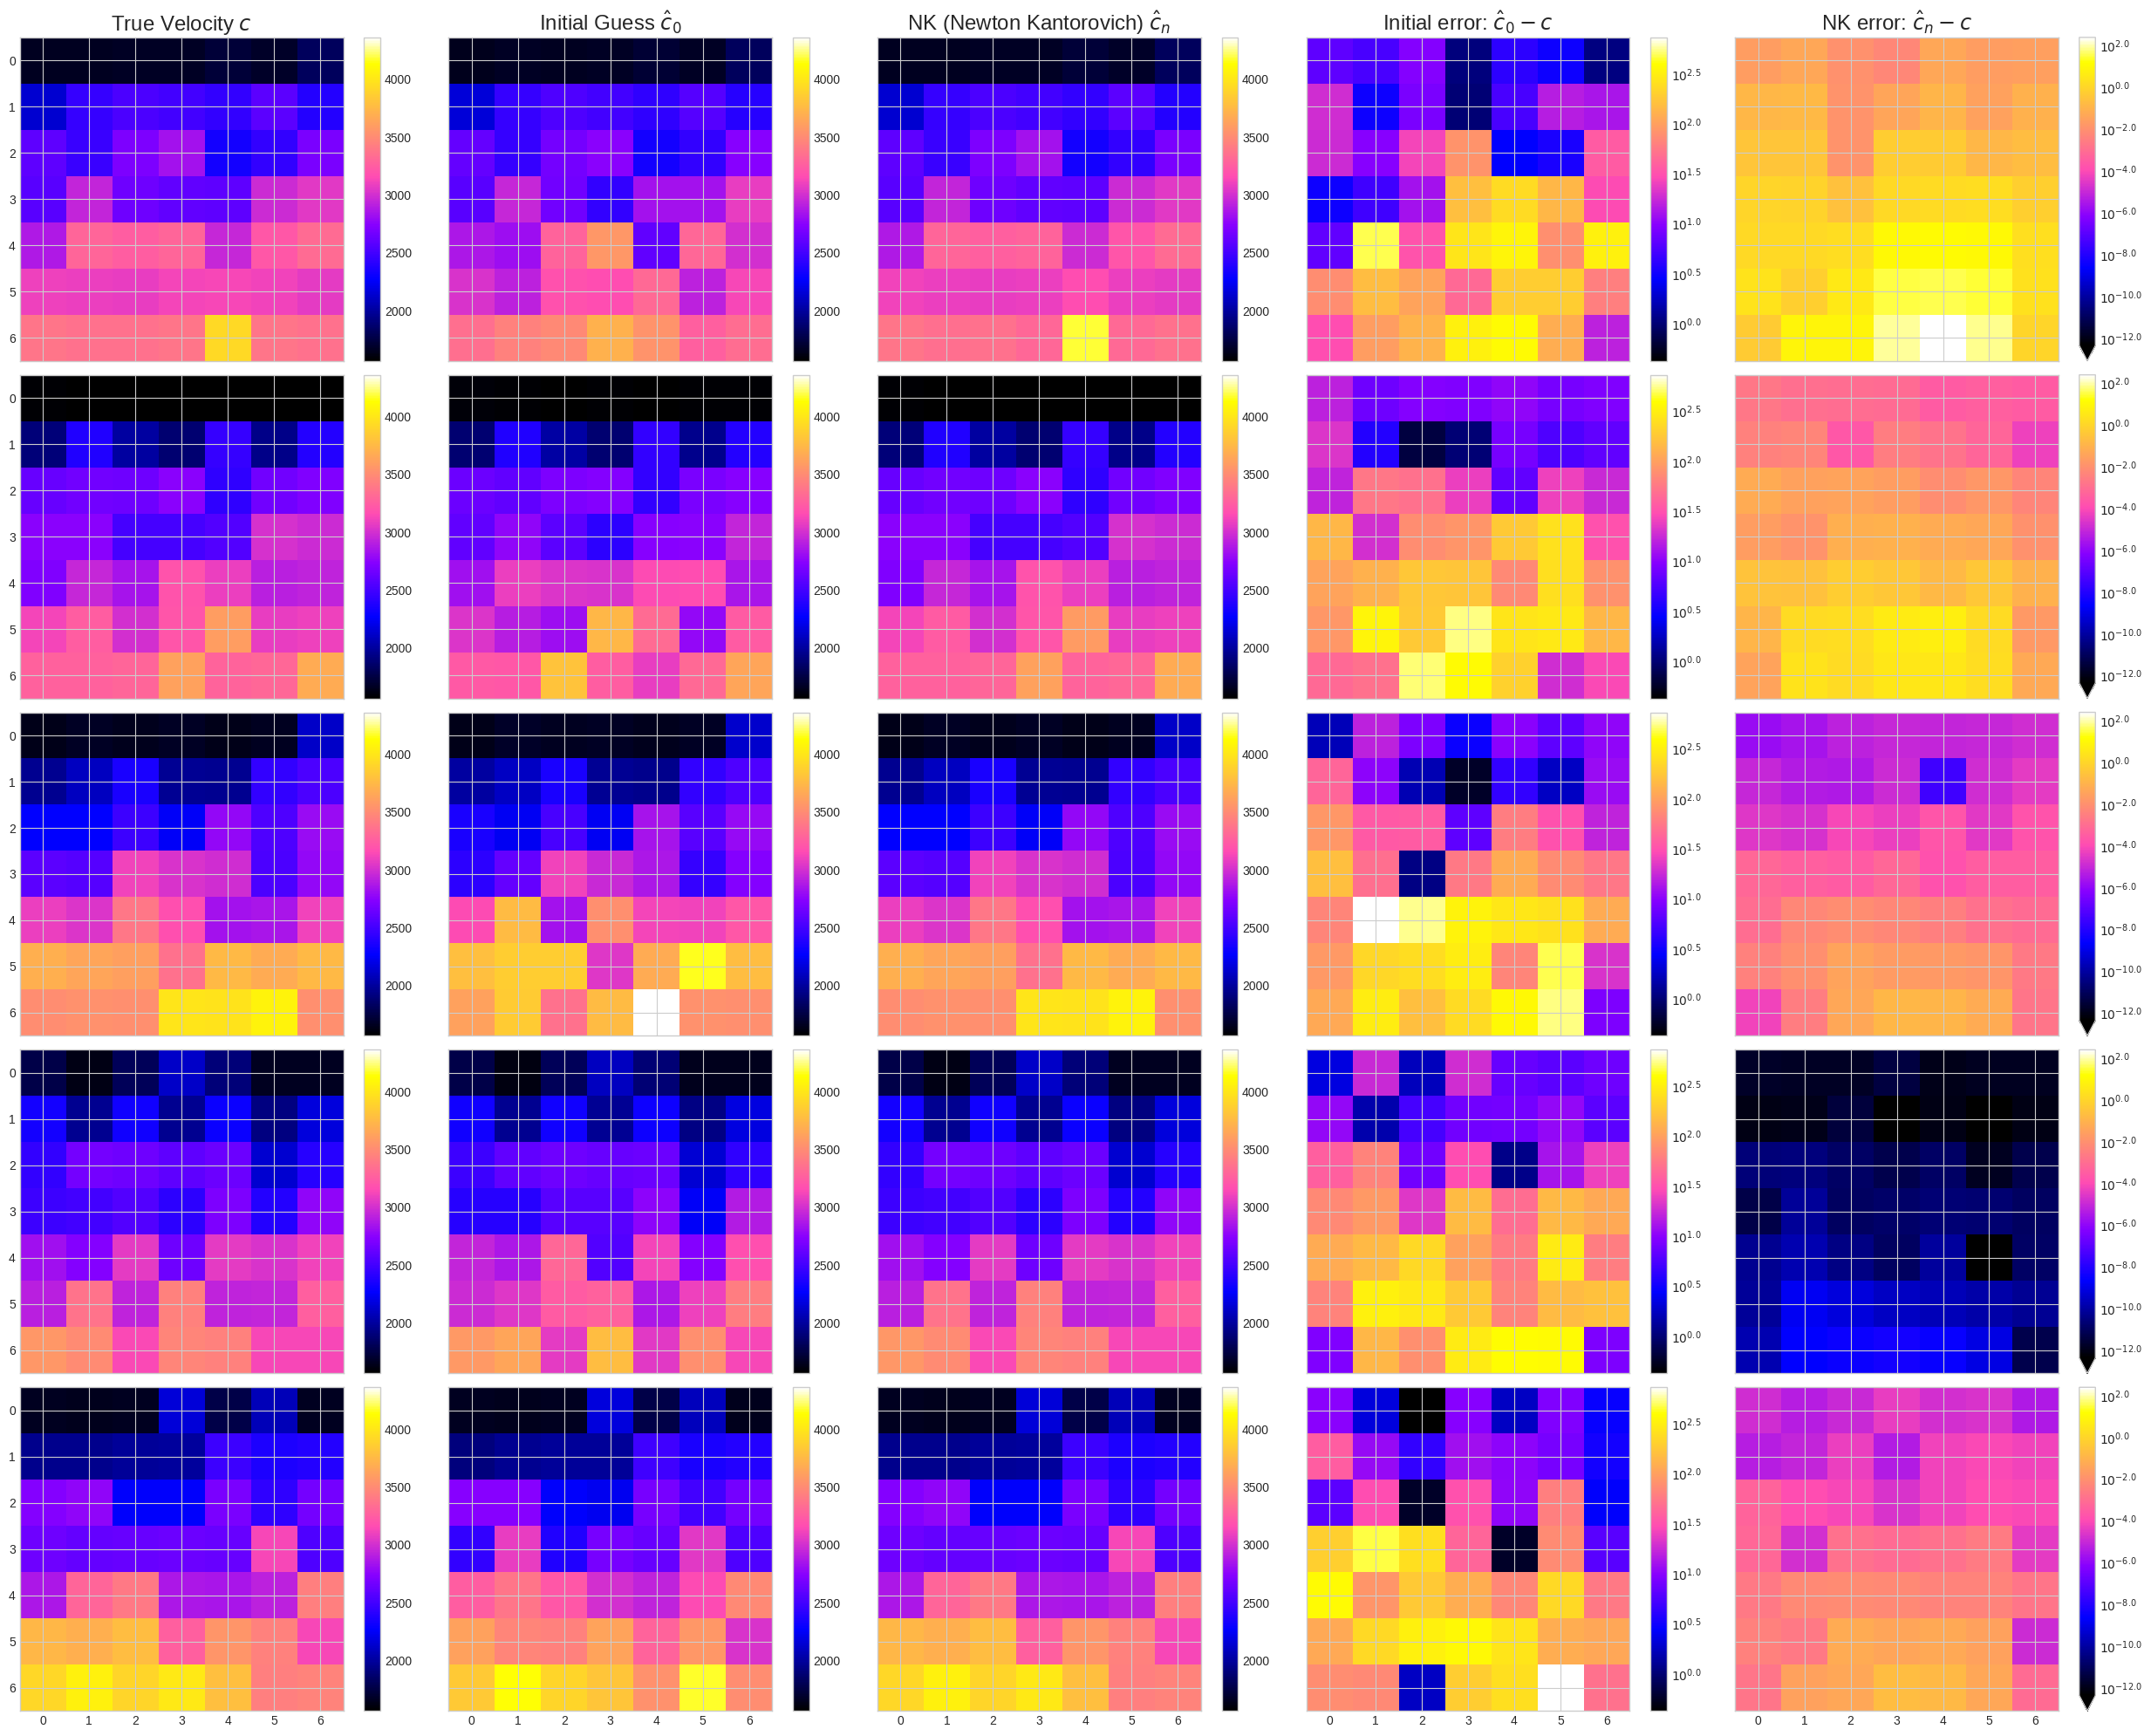

In [59]:
Rplt = 5
print(data_infer["l2rerrors"][:Rplt,0])
print(data_infer["l2rerrors"][:Rplt,-1])
plot_nk_velocities(vref.cpu()[:Rplt],data_infer["vs"][:Rplt,0].cpu(),data_infer["vs"][:Rplt,-1].cpu());

## Check for improved condition numbers

In [88]:
_conds_L_v_u = torch.linalg.cond(L_v_u.to(DEVICE)).to("cpu")
_Thetas_v_u = torch.einsum("...ij,...kj->...ik",L_v_u.to(DEVICE),L_v_u.to(DEVICE))
_conds_Thetas_v_u = torch.linalg.cond(_Thetas_v_u.to(DEVICE)).to("cpu")

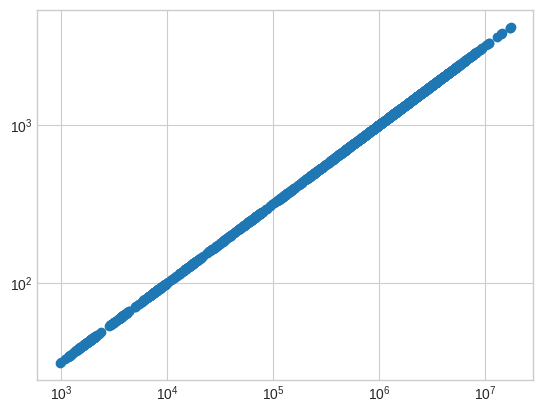

In [92]:
pyplot.scatter(_conds_Thetas_v_u.flatten(),_conds_L_v_u.flatten())
pyplot.yscale('log')
pyplot.xscale('log')

In [ ]:
Lhat_v_u = torch.zeros(L_v_u.shape,device=DEVICE) 
Lhat_v_u[:,lti0,lti1] = outputs_v_hat_sgp
_conds_Lhat_v_u = torch.linalg.cond(Lhat_v_u.to(DEVICE)).to("cpu")


tensor([[102.4103,   0.0000,   0.0000,   0.0000,   0.0000],
        [ 13.9594, 113.9313,   0.0000,   0.0000,   0.0000],
        [ 11.1417, -21.5983, 182.0911,   0.0000,   0.0000],
        [  8.1919,   3.6905,  14.6518, 143.1098,   0.0000],
        [  1.6712,   0.2849,  22.5221,   5.9319, 190.9841]], device='cuda:0')


In [96]:
L2_v_u = torch.linalg.solve_triangular(Lhat_v_u.to(DEVICE),L_v_u.to(DEVICE),upper=False).to("cpu")
_conds_L2_v_u = torch.linalg.cond(L2_v_u.to(DEVICE)).to("cpu")

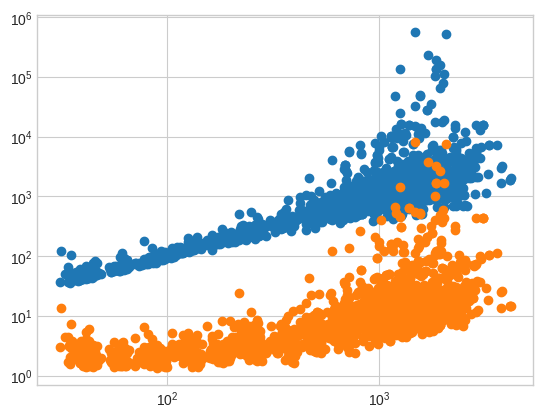

In [97]:
pyplot.scatter(_conds_L_v_u.flatten(),_conds_Lhat_v_u.flatten())
pyplot.scatter(_conds_L_v_u.flatten(),_conds_L2_v_u.flatten())
pyplot.yscale('log')
pyplot.xscale('log')